# Responsible AI: Face Recognition
### Building a gender-neutral, race-agnostic age classifier for retail analytics

---

## Project Context
- **Problem:** Retail analytics systems need age estimation to understand customer demographics
- **Why Responsible AI:** Face images are highly sensitive personal data; systems trained on biased data produce biased outcomes
- **Who is affected:** Any person walking past a retail camera
- **Our Goal:** Build an age classifier whose performance is fair across all races and genders

## Design Decisions (fixed from Day 1)
- Race and gender are **never** used as model inputs
- Race and gender are kept **only** for fairness auditing after training
- No faces are stored — only age-group predictions are output
- System is for **academic research only** — not cleared for deployment

## Datasets & Roles

| Dataset | Role | Reason |
|---|---|---|
| UTKFace | Model training + per-group accuracy testing | Only dataset with continuous age labels plus race and gender |
| FairFace | Fairness testing (prediction consistency) | Balanced across 7 races — ideal bias audit set |
| Adience | **Dropped** | Too small (3,086 images), no race labels, coarse age brackets |

### Note on Dataset Roles
The project brief suggested FairFace as the training anchor with UTKFace/Adience as
held-out test sets. We instead trained on UTKFace (which provides continuous age labels
directly) and used FairFace for fairness testing across race groups, since the Kaggle
mirror of FairFace we accessed only provides race-labeled folders without the original
age/gender label files. This is a deliberate, documented adaptation.

## Licenses & Citations (verified)

**UTKFace** — Non-commercial research use only (official page confirmed).
Zhang, Z., Song, Y., & Qi, H. (2017). *Age Progression/Regression by Conditional
Adversarial Autoencoder.* CVPR 2017.

**FairFace** — CC BY 4.0 (confirmed on official GitHub repo).
Karkkainen, K., & Joo, J. (2021). *FairFace: Face Attribute Dataset for Balanced Race,
Gender, and Age for Bias Measurement and Mitigation.* WACV 2021, pp. 1548-1558.


## ⚡ Recovery Cell — run this first after any server restart
Reinstalls packages and reloads the saved model and data splits if they exist.
Skip straight to the fairness section if the checkpoint loads successfully.

In [1]:
# Recovery Cell — run first after a kernel/server restart.
# Reloads the saved model + data splits if they exist AND are loadable in this
# environment. Never fatal: if the model can't load, the notebook trains fresh.
import os
import pandas as pd
from pathlib import Path

# Vault first — it is the only path that survives a container restart.
CANDIDATES = [
    Path("/home/jovyan/vault/face_project/data"),   # persistent NFS
    Path("/home/jovyan/work/data"),                 # symlink, if present
    Path(os.environ.get("FACE_DATA_ROOT", r"D:\nihal")),   # local machine
]
WORK_DIR = next((c for c in CANDIDATES if c.exists()), CANDIDATES[-1])
MODEL_PATH = str(WORK_DIR / "age_classifier_baseline.keras")
print("WORK_DIR:", WORK_DIR)

# Splits are plain CSVs — always readable, load them independently of the model.
for name in ["train_df", "val_df", "test_df"]:
    p = WORK_DIR / f"{name}.csv"
    if p.exists():
        globals()[name] = pd.read_csv(p)
        print(f"  {name}: {len(globals()[name])} rows")
    else:
        print(f"  {name}: not found — will be created by the split cell below")

# Model load is best-effort: a version mismatch must not halt Run All.
model = None
if os.path.exists(MODEL_PATH):
    try:
        from tensorflow.keras.models import load_model
        model = load_model(MODEL_PATH)
        print("Checkpoint loaded — model restored, training cells can be skipped")
    except Exception as e:
        print(f"Checkpoint present but NOT loadable here: {type(e).__name__}")
        print("  (saved by a different Keras version) — notebook will train from scratch")
else:
    print("No checkpoint found — notebook will train from scratch")

WORK_DIR: /home/jovyan/vault/face_project/data
  train_df: 16578 rows
  val_df: 3553 rows
  test_df: 3553 rows


2026-07-21 13:14:49.740812: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
2026-07-21 13:14:49.741963: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.


Checkpoint loaded — model restored, training cells can be skipped


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:396: UserWarning: Skipping variable loading for optimizer 'adam', because it has 322 variables whereas the saved optimizer has 74 variables. 
  trackable.load_own_variables(weights_store.get(inner_path))


## Imports

In [2]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import json
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully")

All libraries imported successfully


In [4]:
# ============================================================
# Path Configuration  (environment-agnostic)
# Works unchanged in the cloud JupyterHub AND locally.
#   - Cloud: data lives under /home/jovyan/work/data
#   - Local: set FACE_DATA_ROOT, or it defaults to D:\nihal
# Every later cell uses WORK_DIR / the resolved dataset dirs,
# so there are NO hardcoded machine paths below this cell.
# ============================================================
from pathlib import Path
import os
import subprocess

CLOUD_DATA = Path("/home/jovyan/work/data")
LOCAL_ROOT = Path(os.environ.get("FACE_DATA_ROOT", r"D:\nihal"))

if CLOUD_DATA.exists():
    ENV, WORK_DIR = "cloud", CLOUD_DATA
else:
    ENV, WORK_DIR = "local", LOCAL_ROOT

WORK_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = str(WORK_DIR / "age_classifier_baseline.keras")

# Candidate layouts checked in order (cloud extraction layout vs local layout).
UTK_CANDIDATES = [
    CLOUD_DATA / "UTKFace" / "UTKFace",
    LOCAL_ROOT / "utkface",
    LOCAL_ROOT / "UTKFace" / "UTKFace",
]
FF_TRAIN_CANDIDATES = [
    CLOUD_DATA / "FairFace" / "FairFace Race" / "train",
    LOCAL_ROOT / "fairface" / "train",
]
FF_VAL_CANDIDATES = [
    CLOUD_DATA / "FairFace" / "FairFace Race" / "val",
    LOCAL_ROOT / "fairface" / "val",
]

def find_dir(candidates, what):
    for c in candidates:
        if Path(c).exists():
            return Path(c)
    raise FileNotFoundError(
        f"[{what}] not found. Looked in:\n  " +
        "\n  ".join(str(c) for c in candidates) +
        "\n\nFix: set FACE_DATA_ROOT to the folder holding your datasets.")

# If both datasets are already on disk, the download/extract cells will skip.
DATA_ALREADY_PRESENT = (
    any(Path(p).exists() for p in UTK_CANDIDATES) and
    any(Path(p).exists() for p in FF_TRAIN_CANDIDATES)
)

print(f"Environment          : {ENV}")
print(f"WORK_DIR             : {WORK_DIR}")
print(f"Data already present : {DATA_ALREADY_PRESENT}"
      f"  ({'download/extract cells will skip' if DATA_ALREADY_PRESENT else 'will download via Kaggle'})")

Environment          : local
WORK_DIR             : D:\nihal
Data already present : False  (will download via Kaggle)


---
# WEEK 1 — Data Analysis, Planning, Architecture & Regulation
---

**Course goals for Week 1 (from the brief):**
1. Analyze the data
2. Derive a project plan from that analysis
3. Propose a possible architecture
4. Perform a regulatory analysis

**How this notebook covers each part (the sections below, in order):**

| Part | Section in this notebook | Goal it answers |
|---|---|---|
| A | Data Acquisition + Documentation | (context) which data, from where, under what licence |
| B | Data Loading + Cleaning & Privacy | prepares the data; bakes in GDPR data-minimization |
| C | Exploratory Data Analysis (EDA) — Findings 1-5 | **Goal 1: analyze the data** |
| D | Project Plan & Architecture | **Goals 2 & 3: plan + architecture** |
| E | Regulatory Analysis (GDPR + EU AI Act) | **Goal 4: regulatory analysis** |

*Everything runs top-to-bottom. Read the markdown between code cells — that is where the analysis and reasoning live.*

## Data Acquisition

### Credentials Setup

⚠️ **Privacy Notice:**
Kaggle API credentials live in a `kaggle.json` file inside your `WORK_DIR`
(cloud: `/home/jovyan/work/data/`  ·  local: your `FACE_DATA_ROOT`, e.g. `D:
ihal`).

This file:
- Is **never** committed to Git (listed in `.gitignore`)
- Is **never** hardcoded in this notebook
- Is only needed if the datasets are **not already on disk** — the download
  cells auto-skip when `DATA_ALREADY_PRESENT` is `True`.

To reproduce from scratch (no local data yet):
1. Create a Kaggle account → Settings → API → Create New Token
2. Save the downloaded `kaggle.json` into your `WORK_DIR`
3. Run the cells below — credentials load and datasets download automatically

In [5]:
%pip install kaggle -q
print("Kaggle installed")


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Kaggle installed


In [6]:
import os, subprocess
from pathlib import Path

VAULT = Path("/home/jovyan/vault/face_project")
DATA  = VAULT / "data"

print("vault exists:", VAULT.exists())
print("data exists :", DATA.exists())
if DATA.exists():
    print("data contents:", sorted(p.name for p in DATA.iterdir()))

work = Path("/home/jovyan/work")
work.mkdir(exist_ok=True)
link = work / "data"
if not (link.exists() or link.is_symlink()):
    link.symlink_to(DATA)
    print("\nsymlink recreated ->", DATA)
else:
    print("\nsymlink already present ->", link.resolve())

print("cloud path detected:", Path("/home/jovyan/work/data").exists())

vault exists: True
data exists : True
data contents: ['.ipynb_checkpoints', 'FairFace', 'UTKFace', 'age_classifier_224px.keras', 'age_classifier_baseline.keras', 'age_classifier_efficientnetb0_224_recipe2.keras', 'age_classifier_effnetb0_224.keras', 'age_classifier_final_mnv2aug224.keras', 'age_classifier_mnv2_aug_224.keras', 'age_classifier_mobilenetv2_224_recipe2.keras', 'age_classifier_scratch_224.keras', 'age_classifier_scratch_96.keras', 'demo_scorecard.png', 'effnetb0_224.weights.h5', 'fairface-race.zip', 'final_mnv2aug224.weights.h5', 'kaggle.json', 'test_df.csv', 'train_df.csv', 'utkface-new.zip', 'val_df.csv']

symlink recreated -> /home/jovyan/vault/face_project/data
cloud path detected: True


### Download Datasets
Both downloads are idempotent — Kaggle skips files that already exist.
**Order matters:** download first, extract afterwards, so the notebook runs
top-to-bottom on a fresh server.

In [7]:
# Download UTKFace (training data) — skipped if already on disk.
if not DATA_ALREADY_PRESENT:
    subprocess.run(["kaggle", "datasets", "download",
                    "-d", "jangedoo/utkface-new", "-p", str(WORK_DIR)])
else:
    print("UTKFace already present — skipping download")

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
utkface-new.zip: Skipping, found more recently modified local copy (use --force to force download)


In [8]:
# Download FairFace race mirror (fairness testing) — skipped if already on disk.
if not DATA_ALREADY_PRESENT:
    subprocess.run(["kaggle", "datasets", "download",
                    "-d", "abdulwasay551/fairface-race", "-p", str(WORK_DIR)])
    print(os.listdir(str(WORK_DIR)))
else:
    print("FairFace already present — skipping download")

Dataset URL: https://www.kaggle.com/datasets/abdulwasay551/fairface-race
License(s): unknown
fairface-race.zip: Skipping, found more recently modified local copy (use --force to force download)
['utkface-new.zip', 'fairface-race.zip', 'train_df.csv', 'val_df.csv', 'test_df.csv', 'FairFace', 'scratch_cnn_results.json', 'transfer_recipe2_results.json', 'UTKFace']


### Extract Datasets

In [9]:
# Extract UTKFace — skipped if data already on disk (local).
if not DATA_ALREADY_PRESENT:
    shutil.rmtree(str(WORK_DIR / "UTKFace"), ignore_errors=True)
    with zipfile.ZipFile(str(WORK_DIR / "utkface-new.zip"), "r") as z:
        z.extractall(str(WORK_DIR / "UTKFace"))
    print("UTKFace extraction complete")
else:
    print("UTKFace already present — skipping extraction")

UTKFace extraction complete


In [10]:
# Extract FairFace — skipped if data already on disk (local).
if not DATA_ALREADY_PRESENT:
    shutil.rmtree(str(WORK_DIR / "FairFace"), ignore_errors=True)
    with zipfile.ZipFile(str(WORK_DIR / "fairface-race.zip"), "r") as z:
        z.extractall(str(WORK_DIR / "FairFace"))
    print("Extracted:", os.listdir(str(WORK_DIR / "FairFace")))
else:
    print("FairFace already present — skipping extraction")

Extracted: ['FairFace Race']


In [11]:
# Sanity check on the UTKFace download (cloud / first run only).
if not DATA_ALREADY_PRESENT:
    with zipfile.ZipFile(str(WORK_DIR / "utkface-new.zip"), "r") as z:
        jpg_in_zip = sum(1 for f in z.namelist() if f.endswith(".jpg"))
    print("Total jpg files in zip:", jpg_in_zip)
    for root, dirs, files in os.walk(str(WORK_DIR / "UTKFace")):
        jpg_count = sum(1 for f in files if f.endswith(".jpg"))
        if jpg_count > 0:
            print(f"{root}: {jpg_count} jpg files")
else:
    print("Data already present — skipping zip sanity check")

Total jpg files in zip: 66976
D:\nihal/UTKFace/UTKFace: 23708 jpg files
D:\nihal/UTKFace/crop_part1: 9780 jpg files
D:\nihal/UTKFace/utkface_aligned_cropped/UTKFace: 23708 jpg files
D:\nihal/UTKFace/utkface_aligned_cropped/crop_part1: 9780 jpg files


### Path Setup

In [12]:
# Resolve the dataset folders now that the data exists (extracted in the
# cloud, or already on disk locally). Robust to both folder layouts.
UTK_DIR        = find_dir(UTK_CANDIDATES,      "UTKFace image folder")
FAIRFACE_TRAIN = find_dir(FF_TRAIN_CANDIDATES, "FairFace train folder")
FAIRFACE_VAL   = find_dir(FF_VAL_CANDIDATES,   "FairFace val folder")

print("UTKFace images :", UTK_DIR)
print("FairFace train :", FAIRFACE_TRAIN)
print("FairFace val   :", FAIRFACE_VAL)

UTKFace images : /home/jovyan/work/data/UTKFace/UTKFace
FairFace train : /home/jovyan/work/data/FairFace/FairFace Race/train
FairFace val   : /home/jovyan/work/data/FairFace/FairFace Race/val


## Dataset Documentation

### Dataset 1: UTKFace
- **Source:** University of Tennessee, Knoxville
- **Authors:** Zhang, Song & Qi — CVPR 2017
- **License:** Non-commercial research use only
- **Size:** ~23,700 images
- **Labels:** Age (0-116), Gender, Race — encoded in the filename as `age_gender_race_timestamp.jpg`
- **Role in this project:** Training the age classifier + per-group accuracy testing

⚠️ **License Restriction:**
UTKFace is available for **non-commercial research only**. This project is strictly
academic — no commercial deployment is made. Images are not redistributed or modified.

### Dataset 2: FairFace (Kaggle race-labeled mirror)
- **Source:** Karkkainen & Joo — WACV 2021
- **License:** CC BY 4.0 (confirmed on official GitHub)
- **Size:** ~108,000 images
- **Labels:** Race (7 categories) — encoded in the folder structure. **No age or gender labels in this mirror.**
- **Role in this project:** Fairness testing ONLY — never used for training

⚠️ **Known Limitation:**
FairFace images were sourced from the YFCC100M Flickr dataset. Individual subjects did
not explicitly consent to AI training use. This is a known ethical limitation of most
publicly available face datasets. In a real deployment, a lawful basis under GDPR would
be required (see Regulatory Analysis).

## Data Loading

### Load UTKFace
Labels are parsed from filenames: `age_gender_race_timestamp.jpg`.
Malformed filenames are skipped and counted.

In [13]:
RACE_MAP   = {0: "White", 1: "Black", 2: "Asian", 3: "Indian", 4: "Other"}
GENDER_MAP = {0: "Male",  1: "Female"}

rows    = []
skipped = 0

for img in sorted(UTK_DIR.iterdir()):
    if not img.name.endswith(".jpg"):
        skipped += 1
        continue
    parts = img.stem.split("_")
    if len(parts) < 3:                     # malformed filename — cannot parse labels
        skipped += 1
        continue
    try:
        rows.append({
            "filepath" : str(img),
            "age"      : int(parts[0]),
            "gender"   : GENDER_MAP.get(int(parts[1]), "Unknown"),
            "race"     : RACE_MAP.get(int(parts[2]),   "Unknown"),
        })
    except ValueError:                     # non-numeric label — skip
        skipped += 1

df_utk = pd.DataFrame(rows)

print("UTKFace loaded :", len(df_utk), "images")
print("Skipped        :", skipped)
df_utk.head(3)

UTKFace loaded : 23705 images
Skipped        : 3


,filepath,age,gender,race
0,/home/jovyan/work/data/UTKFace/UTKFace/100_0_0...,100,Male,White
1,/home/jovyan/work/data/UTKFace/UTKFace/100_0_0...,100,Male,White
2,/home/jovyan/work/data/UTKFace/UTKFace/100_1_0...,100,Female,White


### Load FairFace
Race is encoded in the folder structure. The timestamp/identity portion of
filenames is never parsed or stored — only the filepath needed to load the image.

In [14]:
rows = []

for race_folder in sorted(FAIRFACE_TRAIN.iterdir()):
    for img in sorted(race_folder.glob("*.jpg")):
        rows.append({"filepath": str(img), "race": race_folder.name, "split": "train"})

for race_folder in sorted(FAIRFACE_VAL.iterdir()):
    for img in sorted(race_folder.glob("*.jpg")):
        rows.append({"filepath": str(img), "race": race_folder.name, "split": "val"})

df_fairface = pd.DataFrame(rows)

print("FairFace loaded :", len(df_fairface), "images")
print("Races           :", sorted(df_fairface["race"].unique()))
df_fairface.head(3)

FairFace loaded : 97698 images
Races           : ['Black', 'East Asian', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'Southeast Asian', 'White']


,filepath,race,split
0,/home/jovyan/work/data/FairFace/FairFace Race/...,Black,train
1,/home/jovyan/work/data/FairFace/FairFace Race/...,Black,train
2,/home/jovyan/work/data/FairFace/FairFace Race/...,Black,train


## Data Cleaning & Privacy

### Clean UTKFace
Filters applied:
- Age restricted to 1–100 (removes label errors like age 0 and 116)
- Rows with unknown gender or race removed
- Age binned into 9 groups for classification

In [15]:
# Canonical age-group order — used everywhere so plots and tables sort correctly
AGE_GROUP_LABELS = ["0-2", "3-9", "10-19", "20-29", "30-39",
                    "40-49", "50-59", "60-69", "70+"]

def age_to_group(age):
    if   age <= 2:  return "0-2"
    elif age <= 9:  return "3-9"
    elif age <= 19: return "10-19"
    elif age <= 29: return "20-29"
    elif age <= 39: return "30-39"
    elif age <= 49: return "40-49"
    elif age <= 59: return "50-59"
    elif age <= 69: return "60-69"
    else:           return "70+"

df_utk_clean = df_utk.copy()
df_utk_clean = df_utk_clean[df_utk_clean["age"] >= 1]
df_utk_clean = df_utk_clean[df_utk_clean["age"] <= 100]
df_utk_clean = df_utk_clean[df_utk_clean["gender"] != "Unknown"]
df_utk_clean = df_utk_clean[df_utk_clean["race"]   != "Unknown"]
df_utk_clean["age_group"] = df_utk_clean["age"].apply(age_to_group)

minors = (df_utk_clean["age"] < 18).sum()

print("Total cleaned images:", len(df_utk_clean))
print("Minors (age < 18)   :", minors)
print("Adults              :", len(df_utk_clean) - minors)
print()
print("Age group distribution:")
print(df_utk_clean["age_group"].value_counts().reindex(AGE_GROUP_LABELS))

Total cleaned images: 23684
Minors (age < 18)   : 4233
Adults              : 19451

Age group distribution:
age_group
0-2      1605
3-9      1457
10-19    1531
20-29    7344
30-39    4536
40-49    2245
50-59    2299
60-69    1316
70+      1351
Name: count, dtype: int64


### Clean FairFace

In [16]:
df_fairface_clean = df_fairface.copy()

# Step 1: keep only files that exist on disk
df_fairface_clean["exists"] = df_fairface_clean["filepath"].apply(os.path.exists)
df_fairface_clean = df_fairface_clean[df_fairface_clean["exists"]].drop(columns=["exists"])

# Step 2: remove nulls
df_fairface_clean = df_fairface_clean.dropna(subset=["race"])

# Step 3: keep only needed columns (data minimization)
df_fairface_clean = df_fairface_clean[["filepath", "race", "split"]]

print("FairFace after cleaning :", len(df_fairface_clean))
print("Races :", sorted(df_fairface_clean["race"].unique()))

FairFace after cleaning : 97698
Races : ['Black', 'East Asian', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'Southeast Asian', 'White']


### GDPR Data Minimization Documentation (Article 5(1)(c))

**Columns DROPPED:**
- Timestamps from UTKFace filenames → no identity linking possible
- Adience `user_id` → entire dataset dropped
- Any metadata not required for the stated purpose

**Columns KEPT and why:**

| Column | Purpose |
|---|---|
| `age` | Prediction target — core purpose of the system |
| `race` | Bias auditing **only** — never fed into the model |
| `gender` | Fairness testing **only** — never fed into the model |
| `filepath` | Needed to load images — not stored after training |

**Children's data (GDPR Art. 8):** minors (age < 18) are present in UTKFace and are
retained for age diversity in training. In a real deployment, parental consent would be
required for anyone under 16 (Germany's threshold).

## Exploratory Data Analysis (EDA)

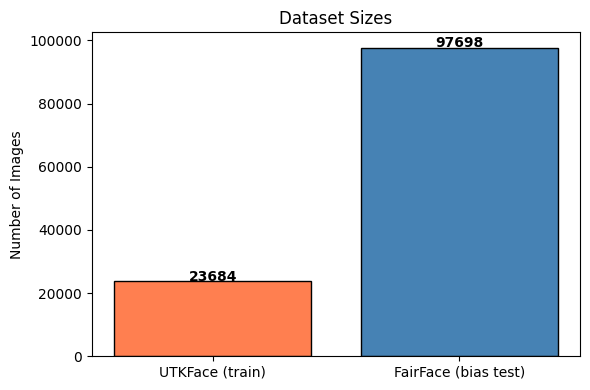

In [17]:
# Dataset sizes at a glance
counts = {"UTKFace (train)": len(df_utk_clean),
          "FairFace (bias test)": len(df_fairface_clean)}

plt.figure(figsize=(6, 4))
plt.bar(counts.keys(), counts.values(), color=["coral", "steelblue"], edgecolor="black")
plt.title("Dataset Sizes")
plt.ylabel("Number of Images")
for i, v in enumerate(counts.values()):
    plt.text(i, v + 100, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

### UTKFace Age Distribution

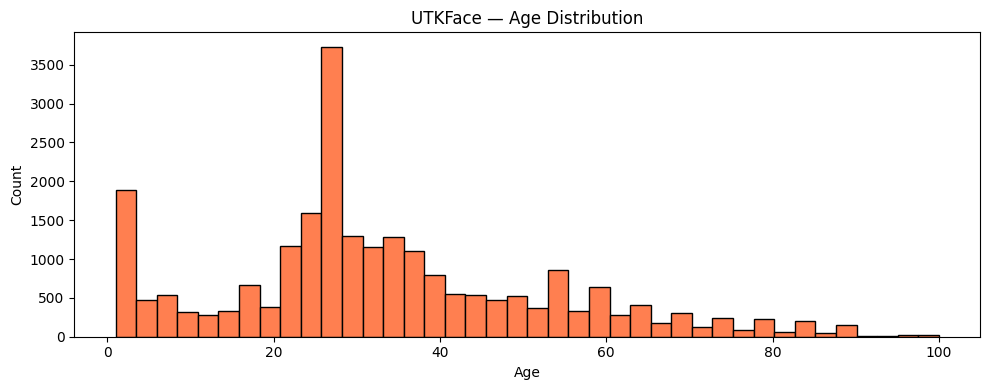

Min age : 1
Max age : 100
Mean age: 33.2


In [18]:
plt.figure(figsize=(10, 4))
plt.hist(df_utk_clean["age"], bins=40, color="coral", edgecolor="black")
plt.title("UTKFace — Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Min age :", df_utk_clean["age"].min())
print("Max age :", df_utk_clean["age"].max())
print("Mean age:", round(df_utk_clean["age"].mean(), 1))

#### Finding 1 — Age Distribution is Heavily Skewed
The histogram shows a strong concentration of faces aged **20-40**.
Faces aged 70+ are severely underrepresented relative to the 20-29 group
(1,351 vs 7,344 images).

**Why this matters:** the model sees far more young/middle-aged faces during training,
so it learns those age groups much better than elderly or infant faces.

**How we address it:** class weights during training make the model pay more attention
to underrepresented groups like 0-2, 60-69 and 70+.

### UTKFace Age Group Distribution

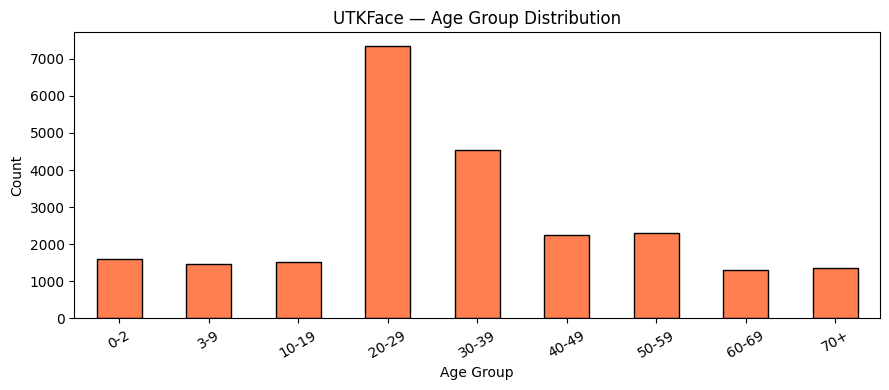

In [19]:
# reindex with AGE_GROUP_LABELS so bars appear in true age order
# (plain sort_index() would sort strings: "10-19" before "3-9")
plt.figure(figsize=(9, 4))
df_utk_clean["age_group"].value_counts().reindex(AGE_GROUP_LABELS).plot(
    kind="bar", color="coral", edgecolor="black"
)
plt.title("UTKFace — Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### UTKFace Race Distribution

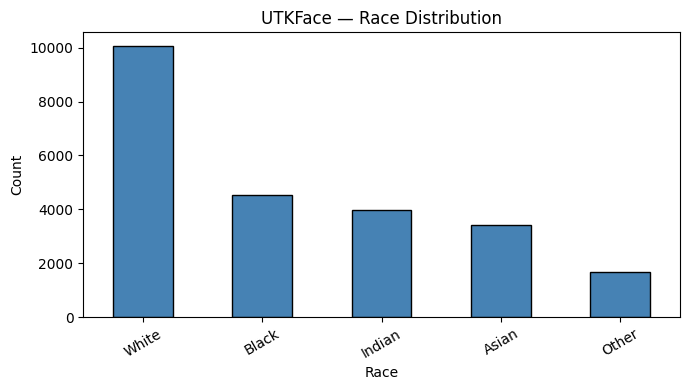

In [20]:
plt.figure(figsize=(7, 4))
df_utk_clean["race"].value_counts().plot(
    kind="bar", color="steelblue", edgecolor="black"
)
plt.title("UTKFace — Race Distribution")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### Finding 2 — White Faces Dominate UTKFace
White faces make up the largest group (~44%), followed by Black and Asian.
This is a known bias in datasets collected from Western internet sources.

**Why this matters:** a model trained on this imbalance may perform differently across
race categories.

**How we address it:** we measure per-race accuracy on the UTKFace test set and test
prediction consistency on FairFace, which is balanced across 7 races. Any gap we find
is quantified — not assumed.

### UTKFace Gender Distribution

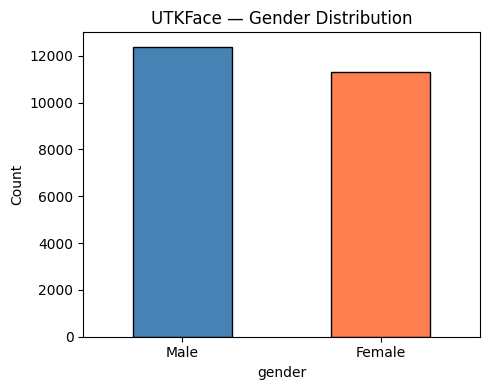

In [21]:
plt.figure(figsize=(5, 4))
df_utk_clean["gender"].value_counts().plot(
    kind="bar", color=["steelblue", "coral"], edgecolor="black"
)
plt.title("UTKFace — Gender Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Finding 3 — Gender is Approximately Balanced
Male and female faces are roughly equal in UTKFace. This is a positive finding —
gender imbalance in training data is less of a concern.

**Note:** gender is never used as a model input. It is retained only to test whether
model accuracy differs by gender — measured in the Week 2 fairness analysis.

### FairFace Race Distribution

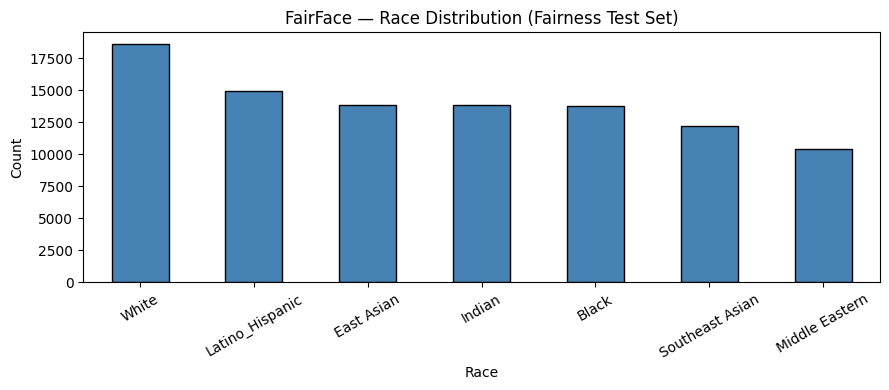

In [22]:
plt.figure(figsize=(9, 4))
df_fairface_clean["race"].value_counts().plot(
    kind="bar", color="steelblue", edgecolor="black"
)
plt.title("FairFace — Race Distribution (Fairness Test Set)")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### Finding 4 — FairFace is Well Balanced Across 7 Races
FairFace shows approximately equal representation across Black, East Asian, Indian,
Latino Hispanic, Middle Eastern, Southeast Asian and White.

**Why this is important:** this balance makes FairFace an ideal fairness test set.
Any differences in prediction behavior across races reflect model behavior — not
differences in how many examples of each race we tested.

### Bias Check: Age by Race

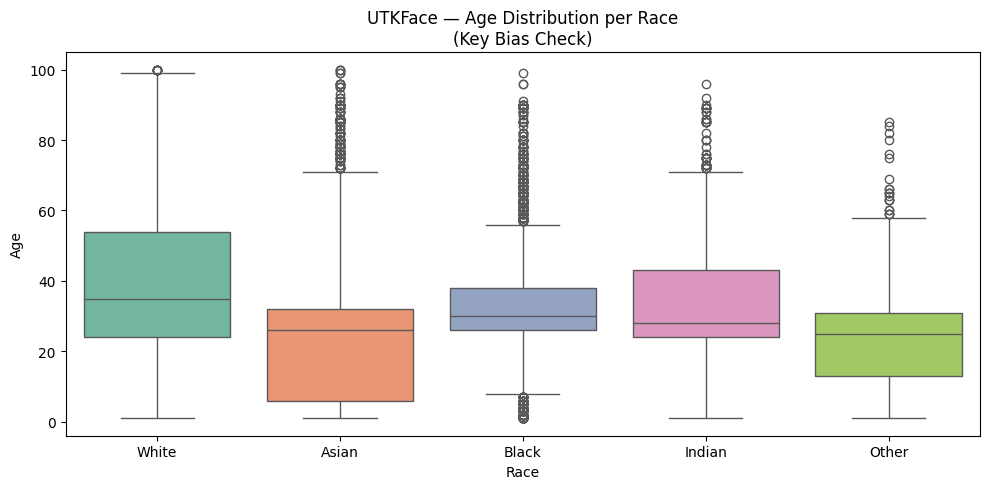

In [23]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_utk_clean, x="race", y="age", palette="Set2")
plt.title("UTKFace — Age Distribution per Race\n(Key Bias Check)")
plt.xlabel("Race")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

#### Finding 5 — Age Range Varies Across Races (Key Bias Risk)
The boxplot shows different age distributions across races in UTKFace. Some races have
fewer elderly or fewer young faces represented.

**What this means:** even with good overall accuracy, the model may fail on specific
age-race combinations that are underrepresented. If Indian elderly faces are rare in
training, the model may consistently predict Indian faces as younger than they are.

**This is the central fairness question our Week 2 analysis answers:**
does model accuracy differ systematically across race groups?

### Sample Images

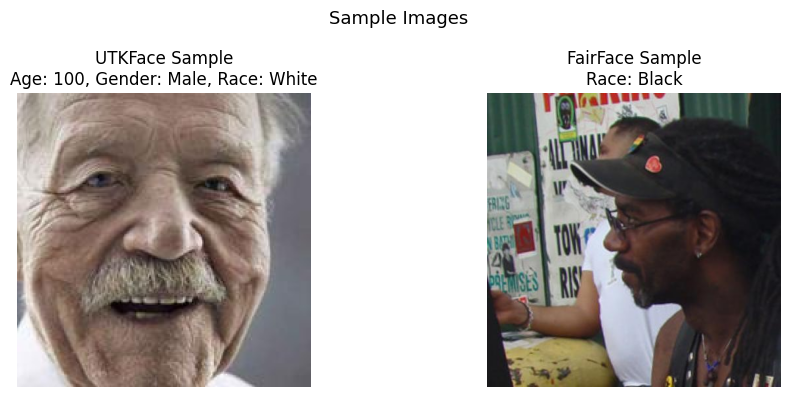

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

img1 = mpimg.imread(df_utk_clean["filepath"].iloc[0])
axes[0].imshow(img1)
axes[0].set_title(f"UTKFace Sample\nAge: {df_utk_clean['age'].iloc[0]}, "
                  f"Gender: {df_utk_clean['gender'].iloc[0]}, "
                  f"Race: {df_utk_clean['race'].iloc[0]}")
axes[0].axis("off")

img2 = mpimg.imread(df_fairface_clean["filepath"].iloc[0])
axes[1].imshow(img2)
axes[1].set_title(f"FairFace Sample\nRace: {df_fairface_clean['race'].iloc[0]}")
axes[1].axis("off")

plt.suptitle("Sample Images", fontsize=13)
plt.tight_layout()
plt.show()

### EDA Summary

| Finding | Impact on Model |
|---|---|
| Young faces (20-40) dominate UTKFace | Model may underperform on elderly and infants |
| White faces outnumber others in UTKFace | Potential accuracy differences across races |
| Gender approximately balanced | Lower gender-bias risk — still verified in Week 2 |
| FairFace balanced across 7 races | Clean fairness test set |
| Minors present in UTKFace (4,233 images) | Documented — special care required in deployment |
| Age 70+ very underrepresented | Class weights applied during training |

**Next step → project plan, architecture and regulatory analysis, then model building.**

## Week 1: Project Plan & Architecture

### Problem Statement
We are building an age classification system for retail analytics. The system estimates
a customer's age group from a face image and must work fairly across all races and genders.

### Dataset Decision

| Dataset | Role | Reason |
|---|---|---|
| UTKFace | Model training + per-group accuracy tests | Continuous age labels, race, gender — most complete |
| FairFace | Fairness testing | Balanced across 7 races — ideal for bias audit |
| Adience | Dropped | Too small (3,086 images), no race labels, rough age brackets |

### Why MobileNetV2
- Lightweight — designed for devices without powerful GPUs (matches our CPU-only server)
- Pretrained on ImageNet — already understands generic visual features
- Transfer learning means far less training data and compute is needed
- Widely used in production retail and mobile systems

### Race-Agnostic Design
- Race is **never** an input to the model
- Gender is **never** an input to the model
- The model sees only raw pixel values
- Fairness is measured after training on both UTKFace (accuracy) and FairFace (consistency)
- This prevents explicit use of protected attributes, while we still audit for implicit bias
  (the model can reconstruct race-correlated signal from pixels — see Risk R3)

### Training Strategy
- Full cleaned dataset: 23,684 images
- Split: 70% train / 15% validation / 15% test, **stratified on age group**
- Class weights compensate for imbalanced age groups
- Two-stage training: (1) frozen MobileNetV2 backbone, (2) fine-tune the last 30 layers
  at a low learning rate
- Optimizer: Adam · Loss: categorical cross-entropy · EarlyStopping on validation accuracy
- No data augmentation in the baseline — considered for Week 3 improvement

In [25]:
# Architecture diagram (display only)
from IPython.display import display, HTML

architecture_html = """
<div style="background:#f8f8f8; border-radius:12px; padding:20px; font-family:sans-serif; max-width:500px; margin:auto;">

  <div style="text-align:center; background:#e8e6f0; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Input</b><br><span style="font-size:12px; color:#555;">Face image — 96×96 RGB</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#d6ede6; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Preprocessing</b><br>
    <span style="font-size:12px; color:#555;">Resize to 96×96 · Normalize pixels ÷ 255</span><br>
    <span style="font-size:11px; color:#c0392b;">⚠ Race & gender: never used as input</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#e0d9f5; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>MobileNetV2 Backbone</b><br>
    <span style="font-size:12px; color:#555;">Pretrained ImageNet · Stage 1: frozen · Stage 2: last 30 layers fine-tuned</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#fde8df; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>GlobalAveragePooling2D</b><br>
    <span style="font-size:12px; color:#555;">Compresses feature maps to a 1D vector</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#fef3d6; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Dropout (0.5)</b><br>
    <span style="font-size:12px; color:#555;">Drops 50% of neurons — prevents overfitting</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#d6ede6; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Dense 128 — ReLU</b><br>
    <span style="font-size:12px; color:#555;">Learns age-specific patterns</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#e0d9f5; border-radius:8px; padding:10px; margin-bottom:8px;">
    <b>Dense 9 — Softmax</b><br>
    <span style="font-size:12px; color:#555;">One probability per age group</span>
  </div>
  <div style="text-align:center; color:#aaa; font-size:18px;">↓</div>

  <div style="text-align:center; background:#e8e6f0; border-radius:8px; padding:10px;">
    <b>Output: Age Group</b><br>
    <span style="font-size:11px; color:#555;">0-2 · 3-9 · 10-19 · 20-29 · 30-39 · 40-49 · 50-59 · 60-69 · 70+</span>
  </div>

</div>
"""

display(HTML(architecture_html))

---
## Week 1: Regulatory Analysis
---

Our system estimates a person's age group from a face image, intended for a retail
analytics context in the EU. Two regulations dominate: the **GDPR** and the **EU AI Act**.
We analyze both honestly, including where classification is genuinely ambiguous —
because getting the classification *right* matters more than defaulting to the
scariest label.

### 1. GDPR — General Data Protection Regulation (EU 2016/679)

**Are face images "biometric data" here?** Under Art. 4(14), biometric data is personal
data from technical processing of physical characteristics **which allows or confirms
the unique identification** of a person. Recital 51 clarifies that photographs are *not*
automatically special-category data — they become biometric data only when processed
through means that enable unique identification.

Our classifier does **not** identify anyone: it maps pixels to one of nine age groups
and discards the image. Strictly read, this may fall outside Art. 9 special-category
processing. However:

- The *training datasets* contain identifiable faces of real people who never consented
  to AI training use — that processing is squarely personal-data processing under GDPR.
- A deployed retail camera would capture images that *could* be used for identification,
  so a Data Protection Authority would likely apply the precautionary reading.

**We therefore treat the data as if Art. 9 applied** — the conservative position —
while documenting the legal nuance.

| Article | Requirement | How we address it |
|---|---|---|
| Art. 4(14) / Rec. 51 | Biometric-data definition | No unique identification performed; conservative Art. 9 treatment applied anyway |
| Art. 5(1)(c) | Data minimization | Only age (target), race and gender (audit-only), and filepath are retained; all other filename metadata dropped |
| Art. 5(1)(b) | Purpose limitation | Race/gender used exclusively for post-hoc fairness auditing, never as model input |
| Art. 6 / 9 | Lawful basis | Academic research context; no deployment. Commercial use would require explicit consent or another Art. 9(2) basis plus an Art. 6 basis |
| Art. 8 | Children's consent (Germany: 16) | Minors are present in UTKFace (4,233 images < 18). Retained for age-diversity in training; flagged as a hard deployment constraint |
| Art. 25 | Privacy by design | No face storage; aggregate age-group output only; protected attributes excluded from the model by construction |
| Art. 35 | DPIA | Systematic monitoring of a publicly accessible area with novel technology → DPIA mandatory before any real deployment |

### 2. EU AI Act (Regulation 2024/1689)

The classification question is subtler than it first appears, and we walk through it
explicitly:

**Prohibited (Art. 5)?** No. Art. 5(1)(g) prohibits biometric categorization that
*infers sensitive attributes* (race, political opinion, religion, sexual orientation…).
Age is not a sensitive attribute in this list, and our system is deliberately designed
**not** to infer race or gender. Real-time remote biometric *identification* in public
spaces (Art. 5(1)(h)) is also prohibited — we perform no identification.

**High-risk (Annex III)?** Annex III point 1(b) covers biometric categorization
*according to sensitive or protected attributes*. Age-group estimation does not
obviously fall under this. So unlike a naive reading, our system is **not clearly
high-risk** — but it is not clearly out of scope either, and guidance is still evolving.
A deployer should obtain a formal legal assessment.

**Transparency obligations (Art. 50)** apply in any case: people exposed to a biometric
categorization system must be informed of its operation. In a retail store this means
visible signage and accessible information — non-negotiable.

| Question | Answer |
|---|---|
| Prohibited practice? | No — no sensitive-attribute inference, no identification |
| High-risk (Annex III 1(b))? | Ambiguous — age is not a "sensitive or protected attribute"; conservative deployers should assume yes until guidance settles |
| Transparency (Art. 50)? | Yes — mandatory disclosure to affected persons |
| If treated as high-risk | Conformity assessment, risk-management system, per-demographic accuracy documentation, human oversight, EU database registration |

### 3. What this means for our project

This project is **research only**: no individuals are processed in real time, no faces
are stored or transmitted, no consequential decisions are made, and all results and
limitations are documented in this notebook. The per-demographic accuracy documentation
the AI Act would demand of a high-risk deployer is exactly what our Week 2 fairness
analysis produces — so our academic work doubles as the compliance groundwork a real
deployment would need.

### 4. Unresolved ethical tension

Both UTKFace and FairFace contain faces scraped from the internet without subject
consent (FairFace derives from YFCC100M/Flickr). This is a known, unresolved problem in
computer vision research. We use the data under its academic licenses (UTKFace:
non-commercial research only; FairFace: CC BY 4.0), acknowledge the tension explicitly,
and note that no commercial use of models trained on this data would be defensible
without establishing a lawful basis for the underlying processing.

---
# WEEK 2 - Baseline Model, Model Selection & Fairness
---

**Goals:** build a baseline age classifier, select a final model, and measure
whether its errors are distributed equally across race groups.

**What this section does**

| Step | Model | Purpose |
|---|---|---|
| 2a | **v1 baseline** - 96px MobileNetV2, no augmentation | establishes a floor |
| 2b | **v7 final** - 224px MobileNetV2 + augmentation + LR decay | the selected model |
| 2c | Fairness audit | per-race accuracy, parity gap for both |

Several architectures and training configurations were trialled during
development (different resolutions, augmentation settings, backbones and
optimisation schedules). **v7** was selected as the final model on the basis of
accuracy and one-off accuracy. Only the baseline and the selected model are
retained here; the intermediate trials are omitted for clarity.

**Fairness metrics used**
- **Accuracy parity gap** = best-group accuracy minus worst-group accuracy (percentage points)
- **Per-race accuracy** = accuracy computed separately for each race group

Race is **never an input** to either model - it is retained only as evaluation
metadata, so any measured gap arises from the images themselves.


### Train / Validation / Test Split

Stratified on the age label so every split has the same age distribution. Race is not used for stratification.

In [26]:
import numpy as np, pandas as pd, tensorflow as tf
from sklearn.model_selection import train_test_split

AGE_GROUP_MAP = {label: i for i, label in enumerate(AGE_GROUP_LABELS)}
NUM_CLASSES   = len(AGE_GROUP_MAP)
SEED          = 42

df_utk_clean["label"] = df_utk_clean["age_group"].map(AGE_GROUP_MAP)

train_df, temp_df = train_test_split(
    df_utk_clean, test_size=0.30, stratify=df_utk_clean["label"], random_state=SEED)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train {len(train_df):,} | Val {len(val_df):,} | Test {len(test_df):,}")
print(f"Classes: {NUM_CLASSES}  ->  {AGE_GROUP_LABELS}")

# persist so later sections can run standalone
for name, d in [("train_df", train_df), ("val_df", val_df), ("test_df", test_df)]:
    d.to_csv(WORK_DIR / f"{name}.csv", index=False)
print("splits saved to", WORK_DIR)


Train 16,578 | Val 3,553 | Test 3,553
Classes: 9  ->  ['0-2', '3-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']
splits saved to D:\nihal


### Load Images

Loaded once at both resolutions and held as **uint8** to keep memory low (~0.65 GB at 96px, ~3.6 GB at 224px). Normalisation happens inside each model's input pipeline, because the two models expect different ranges:

- **v1** was trained on `[0, 1]` - the pipeline divides by 255
- **v7** has a `Rescaling` layer built in - it receives raw `[0, 255]`

In [27]:
from PIL import Image
from concurrent.futures import ThreadPoolExecutor

def load_images(df, size, workers=8):
    """Load images as uint8 [0,255]. Row i matches df.iloc[i]."""
    paths = df["filepath"].astype(str).values
    out   = np.zeros((len(paths), size, size, 3), np.uint8)
    def _one(i):
        out[i] = np.asarray(Image.open(paths[i]).convert("RGB")
                            .resize((size, size), Image.BILINEAR))
    with ThreadPoolExecutor(workers) as ex:
        list(ex.map(_one, range(len(paths))))
    return out

def onehot(df):
    return tf.keras.utils.to_categorical(df["label"].values, NUM_CLASSES).astype(np.float32)

# ---- 96px (for the v1 baseline) ----
X_tr96, X_va96, X_te96 = (load_images(d, 96) for d in (train_df, val_df, test_df))
# ---- 224px (for v7) ----
X_tr224, X_va224, X_te224 = (load_images(d, 224) for d in (train_df, val_df, test_df))

y_tr, y_va, y_te = onehot(train_df), onehot(val_df), onehot(test_df)
y_true_test = np.argmax(y_te, axis=1)

tot = sum(a.nbytes for a in [X_tr96, X_va96, X_te96, X_tr224, X_va224, X_te224]) / 1e9
print(f"96px  train {X_tr96.shape}   224px train {X_tr224.shape}")
print(f"image memory: {tot:.2f} GB (uint8)")


96px  train (16578, 96, 96, 3)   224px train (16578, 224, 224, 3)
image memory: 4.22 GB (uint8)


### Class Weights

The `20-29` band is ~31% of the data. Without weighting the model can score 31% by always predicting it. Rare bands are up-weighted so the loss forces the model to learn them.

In [28]:
from sklearn.utils.class_weight import compute_class_weight

cw = compute_class_weight("balanced",
                          classes=np.arange(NUM_CLASSES),
                          y=train_df["label"].values)
class_weight = {i: float(w) for i, w in enumerate(cw)}
w_train = np.array([class_weight[int(l)] for l in train_df["label"].values], np.float32)

for i, lab in enumerate(AGE_GROUP_LABELS):
    print(f"  {lab:<7} weight {class_weight[i]:.2f}   "
          f"n={int((train_df['label']==i).sum()):,}")


  0-2     weight 1.64   n=1,123
  3-9     weight 1.81   n=1,020
  10-19   weight 1.72   n=1,072
  20-29   weight 0.36   n=5,141
  30-39   weight 0.58   n=3,175
  40-49   weight 1.17   n=1,571
  50-59   weight 1.14   n=1,609
  60-69   weight 2.00   n=921
  70+     weight 1.95   n=946


### Data Pipeline Helper

Arrays stay in host RAM and stream to the GPU in batches - passing a multi-GB array straight to `.fit()` copies it wholesale to the GPU and causes out-of-memory errors.

In [29]:
BATCH_SIZE = 32

def make_ds(X, y, scale01=False, w=None, shuffle=False):
    """X: uint8 [0,255]. scale01=True divides by 255 (for v1)."""
    tensors = (X, y, w) if w is not None else (X, y)
    with tf.device("/CPU:0"):                 # keeps the big array off the GPU
        ds = tf.data.Dataset.from_tensor_slices(tensors)
    def _prep(a, b, *rest):
        a = tf.cast(a, tf.float32)
        if scale01:
            a = a / 255.0
        return (a, b) + rest
    ds = ds.map(_prep, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(2048, seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("pipeline ready")


pipeline ready


---
## Week 2a - Baseline Model (v1)
---

**MobileNetV2 @ 96px, ImageNet weights, no augmentation.**

Two-stage transfer learning:
1. **Stage 1** - backbone frozen, only the new head trains (LR 1e-4)
2. **Stage 2** - last 30 layers unfrozen and fine-tuned at a 10x lower LR (1e-5)

The low fine-tuning LR matters: pretrained weights are already meaningful, and a
large learning rate destroys them in the first few steps.


In [30]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
import time

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

base_v1 = MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights="imagenet")
base_v1.trainable = False

inp = layers.Input((96, 96, 3))
x   = base_v1(inp, training=False)            # no augmentation in the baseline
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dropout(0.5)(x)
x   = layers.Dense(128, activation="relu")(x)
out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model_v1 = Model(inp, out, name="v1_baseline_96")

model_v1.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                 loss="categorical_crossentropy", metrics=["accuracy"])
print(f"v1 parameters: {model_v1.count_params():,}")

tr1 = make_ds(X_tr96, y_tr, scale01=True, w=w_train, shuffle=True)
va1 = make_ds(X_va96, y_va, scale01=True)

t0 = time.time()
print("\n=== v1 STAGE 1 (frozen backbone) ===")
h1_v1 = model_v1.fit(tr1, validation_data=va1, epochs=26,
                     callbacks=[EarlyStopping(monitor="val_accuracy", patience=6,
                                              restore_best_weights=True, verbose=1)],
                     verbose=1)

print("\n=== v1 STAGE 2 (fine-tune last 30 layers) ===")
base_v1.trainable = True
for l in base_v1.layers[:-30]:
    l.trainable = False
model_v1.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                 loss="categorical_crossentropy", metrics=["accuracy"])
h2_v1 = model_v1.fit(tr1, validation_data=va1, epochs=30,
                     callbacks=[EarlyStopping(monitor="val_accuracy", patience=6,
                                              restore_best_weights=True, verbose=1)],
                     verbose=1)

MODEL_V1 = WORK_DIR / "v1_baseline_96.keras"
model_v1.save(MODEL_V1)
print(f"\nv1 trained in {(time.time()-t0)/60:.1f} min  ->  {MODEL_V1.name}")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
v1 parameters: 2,423,113

=== v1 STAGE 1 (frozen backbone) ===
Epoch 1/26


I0000 00:00:1784640215.888760     624 service.cc:145] XLA service 0x7fec60002de0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784640215.889020     624 service.cc:153]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
I0000 00:00:1784640215.889023     624 service.cc:153]   StreamExecutor device (1): NVIDIA RTX A6000, Compute Capability 8.6


 51/519 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1320 - loss: 2.8637

I0000 00:00:1784640218.491974     624 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


519/519 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1642 - loss: 2.4582

I0000 00:00:1784640223.089760    1891 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_1184', 32 bytes spill stores, 32 bytes spill loads

I0000 00:00:1784640223.111208    1871 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_1184', 244 bytes spill stores, 244 bytes spill loads



519/519 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.1643 - loss: 2.4577 - val_accuracy: 0.2958 - val_loss: 1.7796
Epoch 2/26
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2679 - loss: 1.8725 - val_accuracy: 0.3318 - val_loss: 1.6767
Epoch 3/26
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3032 - loss: 1.7221 - val_accuracy: 0.3484 - val_loss: 1.6308
Epoch 4/26
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3154 - loss: 1.6620 - val_accuracy: 0.3586 - val_loss: 1.5650
Epoch 5/26
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3356 - loss: 1.6130 - val_accuracy: 0.3707 - val_loss: 1.5545
Epoch 6/26
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3531 - loss: 1.5779 - val_accuracy: 0.3743 - val_loss: 1.5449
Epoch 7/26
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3660 - loss: 1.5507 - val_accuracy: 0.3771 - val_loss: 1.5298
Epoch 8/26
519/519 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3645 - loss: 1.5400 - val_accuracy: 0.3873 - va

### v1 Baseline - Test Results

In [31]:
te1 = make_ds(X_te96, y_te, scale01=True)
p_v1 = model_v1.predict(te1, verbose=0)
yp_v1 = np.argmax(p_v1, axis=1)

acc_v1    = float((yp_v1 == y_true_test).mean())
oneoff_v1 = float((np.abs(yp_v1 - y_true_test) <= 1).mean())

ev1 = test_df.copy()
ev1["y_pred"], ev1["correct"] = yp_v1, yp_v1 == y_true_test
race_v1 = ev1.groupby("race")["correct"].mean().sort_values()
gap_v1  = float(race_v1.max() - race_v1.min())

print(f"=== v1 BASELINE (96px, no augmentation) ===")
print(f"  exact-band accuracy : {acc_v1:.2%}")
print(f"  one-off accuracy    : {oneoff_v1:.2%}\n")
for r, v in race_v1.items():
    print(f"    {r:<8} {v:.2%}")
print(f"\n  accuracy parity gap : {gap_v1*100:.2f}pp "
      f"(best {race_v1.idxmax()}, worst {race_v1.idxmin()})")


=== v1 BASELINE (96px, no augmentation) ===
  exact-band accuracy : 46.64%
  one-off accuracy    : 84.35%

    Black    40.76%
    White    43.61%
    Indian   48.17%
    Other    52.50%
    Asian    59.29%

  accuracy parity gap : 18.53pp (best Asian, worst Black)


---
## Week 2b - Final Model (v7)
---

After trialling several configurations - different input resolutions, backbones,
augmentation settings and optimisation schedules - **v7** was selected as the
final model.

**What v7 changes relative to the baseline**

| | v1 baseline | v7 final |
|---|---|---|
| Input resolution | 96 x 96 | **224 x 224** |
| Augmentation | none | **flip, rotation, zoom, contrast** |
| Input scaling | `[0,1]` | **`[-1,1]` via a built-in `Rescaling` layer** |
| Fine-tuning | last 30 layers | **full backbone unfrozen** |
| Schedule | fixed LR | **ReduceLROnPlateau + EarlyStopping on `val_accuracy`** |

Several factors change together, so the improvement cannot be attributed to any
single one - this is a baseline-versus-final comparison, not a controlled ablation.


In [50]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import time

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.10, seed=SEED),
    layers.RandomZoom(0.10, seed=SEED),
    layers.RandomContrast(0.10, seed=SEED),
], name="augmentation")

base_v7 = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_v7.trainable = False

inp = layers.Input((224, 224, 3))
x   = aug(inp)
x   = layers.Rescaling(1/127.5, offset=-1.0)(x)     # [0,255] -> [-1,1]
x   = base_v7(x, training=False)
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(256, use_bias=False)(x)
x   = layers.BatchNormalization()(x)
x   = layers.ReLU()(x)
x   = layers.Dropout(0.4)(x)
out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model_v7 = Model(inp, out, name="v7_final_224")
print(f"v7 parameters: {model_v7.count_params():,}")

tr7 = make_ds(X_tr224, y_tr, w=w_train, shuffle=True)   # raw [0,255]
va7 = make_ds(X_va224, y_va)

MODEL_V7 = WORK_DIR / "v7_final_224.keras"
t0 = time.time()

model_v7.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                 loss="categorical_crossentropy", metrics=["accuracy"])
print("\n=== v7 STAGE 1 (frozen backbone, warm-up) ===")
h1_v7 = model_v7.fit(tr7, validation_data=va7, epochs=5, verbose=1)

base_v7.trainable = True
model_v7.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                 loss="categorical_crossentropy", metrics=["accuracy"])
print("\n=== v7 STAGE 2 (full unfreeze + LR decay) ===")
h2_v7 = model_v7.fit(
    tr7, validation_data=va7, epochs=35,
    callbacks=[
        ReduceLROnPlateau(monitor="val_accuracy", mode="max", factor=0.4,
                          patience=3, min_lr=1e-7, verbose=1),
        EarlyStopping(monitor="val_accuracy", mode="max", patience=7,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(str(MODEL_V7), monitor="val_accuracy", mode="max",
                        save_best_only=True),
    ], verbose=1)

model_v7.save(MODEL_V7)
print(f"\nv7 trained in {(time.time()-t0)/60:.1f} min  ->  {MODEL_V7.name}")

v7 parameters: 2,589,001

=== v7 STAGE 1 (frozen backbone, warm-up) ===
Epoch 1/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.3116 - loss: 1.8432 - val_accuracy: 0.3130 - val_loss: 1.6548
Epoch 2/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.3827 - loss: 1.4673 - val_accuracy: 0.3594 - val_loss: 1.5400
Epoch 3/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.4083 - loss: 1.3947 - val_accuracy: 0.3417 - val_loss: 1.5854
Epoch 4/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.4181 - loss: 1.3487 - val_accuracy: 0.3538 - val_loss: 1.5471
Epoch 5/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.4325 - loss: 1.3289 - val_accuracy: 0.3881 - val_loss: 1.4858

=== v7 STAGE 2 (full unfreeze + LR decay) ===
Epoch 1/35
519/519 ━━━━━━━━━━━━━━━━━━━━ 59s 96ms/step - accuracy: 0.3432 - loss: 1.6173 - val_accuracy: 0.3884 - val_loss: 1.6322 - learning_rate: 1.0000e-04
Epoch 2/35
519/519 ━━━━━━━━━━━━━━━━━━━━ 49s 95ms/step - accuracy: 0.4486 - los

### v7 Final - Test Results

In [51]:
te7 = make_ds(X_te224, y_te)
p_v7  = model_v7.predict(te7, verbose=0)
yp_v7 = np.argmax(p_v7, axis=1)

acc_v7    = float((yp_v7 == y_true_test).mean())
oneoff_v7 = float((np.abs(yp_v7 - y_true_test) <= 1).mean())

test_eval = test_df.copy()
test_eval["y_true"]  = y_true_test
test_eval["y_pred"]  = yp_v7
test_eval["correct"] = yp_v7 == y_true_test
race_v7 = test_eval.groupby("race")["correct"].mean().sort_values()
gap_v7  = float(race_v7.max() - race_v7.min())

print(f"=== v7 FINAL (224px + augmentation + LR decay) ===")
print(f"  exact-band accuracy : {acc_v7:.2%}")
print(f"  one-off accuracy    : {oneoff_v7:.2%}\n")
for r, v in race_v7.items():
    print(f"    {r:<8} {v:.2%}")
print(f"\n  accuracy parity gap : {gap_v7*100:.2f}pp "
      f"(best {race_v7.idxmax()}, worst {race_v7.idxmin()})")


=== v7 FINAL (224px + augmentation + LR decay) ===
  exact-band accuracy : 54.69%
  one-off accuracy    : 90.29%

    White    51.48%
    Black    52.05%
    Indian   54.09%
    Other    60.42%
    Asian    66.01%

  accuracy parity gap : 14.52pp (best Asian, worst White)


### Week 2c - Baseline vs Final

,metric,v1 baseline (96px),v7 final (224px)
0,exact accuracy,46.64%,54.69%
1,one-off accuracy,84.35%,90.29%
2,race parity gap (pp),18.53,14.52


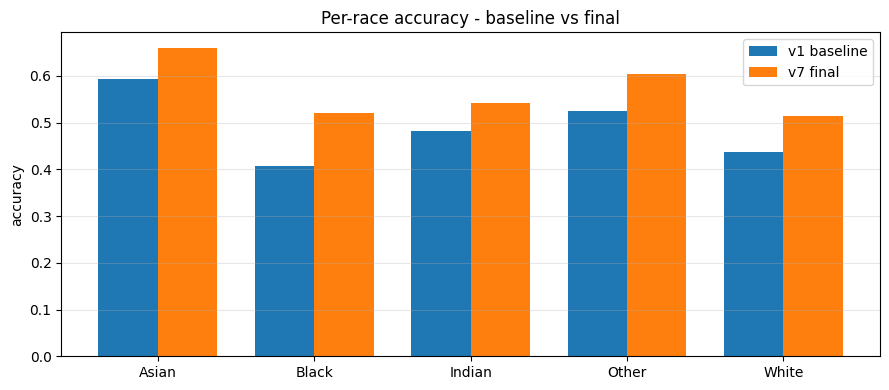

accuracy   46.64% -> 54.69%   (+8.05pp)
one-off    84.35% -> 90.29%   (+5.94pp)
race gap   18.53pp -> 14.52pp   (-4.00pp)


In [52]:
import matplotlib.pyplot as plt

cmp = pd.DataFrame({
    "metric": ["exact accuracy", "one-off accuracy", "race parity gap (pp)"],
    "v1 baseline (96px)": [f"{acc_v1:.2%}", f"{oneoff_v1:.2%}", f"{gap_v1*100:.2f}"],
    "v7 final (224px)"  : [f"{acc_v7:.2%}", f"{oneoff_v7:.2%}", f"{gap_v7*100:.2f}"],
})
display(cmp)

fig, ax = plt.subplots(figsize=(9, 4))
races = sorted(set(race_v1.index) | set(race_v7.index))
xs = np.arange(len(races)); w = 0.38
ax.bar(xs - w/2, [race_v1.get(r, 0) for r in races], w, label="v1 baseline")
ax.bar(xs + w/2, [race_v7.get(r, 0) for r in races], w, label="v7 final")
ax.set_xticks(xs); ax.set_xticklabels(races)
ax.set_ylabel("accuracy"); ax.set_title("Per-race accuracy - baseline vs final")
ax.legend(); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

print(f"accuracy   {acc_v1:.2%} -> {acc_v7:.2%}   ({(acc_v7-acc_v1)*100:+.2f}pp)")
print(f"one-off    {oneoff_v1:.2%} -> {oneoff_v7:.2%}   ({(oneoff_v7-oneoff_v1)*100:+.2f}pp)")
print(f"race gap   {gap_v1*100:.2f}pp -> {gap_v7*100:.2f}pp   "
      f"({(gap_v7-gap_v1)*100:+.2f}pp)")


---
# WEEK 3 - Explainability, Error Structure & Statistical Confidence
---

All analysis in this section uses the **final model, v7**.

**Goals**
- open the model with an XAI method (Grad-CAM) and compare **where the baseline
  and the final model look**
- quantify the *structure* of the errors (confusion matrix, one-off accuracy)
- locate intersectional failure cells (per-age x per-race grid)
- put confidence bounds on the fairness gap (bootstrap)


## XAI Method: Grad-CAM

Grad-CAM produces a heat map showing which image regions drove the prediction. It
takes the gradient of the predicted class score with respect to the last
convolutional feature map, pools those gradients per channel to get an importance
weight, and forms a weighted sum of the feature maps.

**Why the last conv layer:** early layers keep spatial detail but only encode
edges; after global pooling all spatial information is gone. The final conv layer
is the last point that is both spatially located and semantically meaningful.

**Note on comparability.** v1 is 96px (3x3 feature map) and v7 is 224px (7x7), so
raw heat maps are different sizes. Both are resized to a common grid before being
split into vertical thirds, so the numbers can be compared directly.

In [53]:
def _unwrap(t):
    return t[0] if isinstance(t, (list, tuple)) else t

def make_gradcam(m):
    """Works for a flat model and for one with a nested backbone."""
    base = next((l for l in m.layers
                 if isinstance(l, tf.keras.Model) and len(l.layers) > 10), None)
    if base is not None:                                  # nested (v1 and v7 both)
        head = m.layers[m.layers.index(base) + 1:]
        def f(x):
            with tf.GradientTape() as t:
                conv = base(x, training=False)
                t.watch(conv)
                h = conv
                for l in head:
                    h = l(h, training=False)
                ch = h[:, tf.argmax(h[0])]
            return conv, t.gradient(ch, conv)
        return f, f"{base.name}/{base.layers[-1].name}"
    target = [l for l in m.layers if isinstance(l, tf.keras.layers.Conv2D)][-1]
    gm = tf.keras.Model(_unwrap(m.input), [_unwrap(target.output), _unwrap(m.output)])
    def f(x):
        with tf.GradientTape() as t:
            conv, pred = gm(x, training=False)
            ch = pred[:, tf.argmax(pred[0])]
        return conv, t.gradient(ch, conv)
    return f, target.name

def heatmap(gc, x):
    conv, grads = gc(x)
    w  = tf.reduce_mean(grads, axis=(0, 1, 2))
    hm = tf.squeeze(conv[0] @ w[:, tf.newaxis])
    hm = tf.maximum(hm, 0)
    return (hm / (tf.reduce_max(hm) + 1e-8)).numpy()

gc_v1, layer_v1 = make_gradcam(model_v1)
gc_v7, layer_v7 = make_gradcam(model_v7)
print(f"v1 tap: {layer_v1}   heatmap {heatmap(gc_v1, X_te96[0:1].astype(np.float32)/255.).shape}")
print(f"v7 tap: {layer_v7}   heatmap {heatmap(gc_v7, X_te224[0:1].astype(np.float32)).shape}")


v1 tap: mobilenetv2_1.00_96/out_relu   heatmap (3, 3)
v7 tap: mobilenetv2_1.00_224/out_relu   heatmap (7, 7)


### Grad-CAM: Baseline vs Final on the Same Faces

Same four test faces through both models. Red marks the regions that drove each prediction.

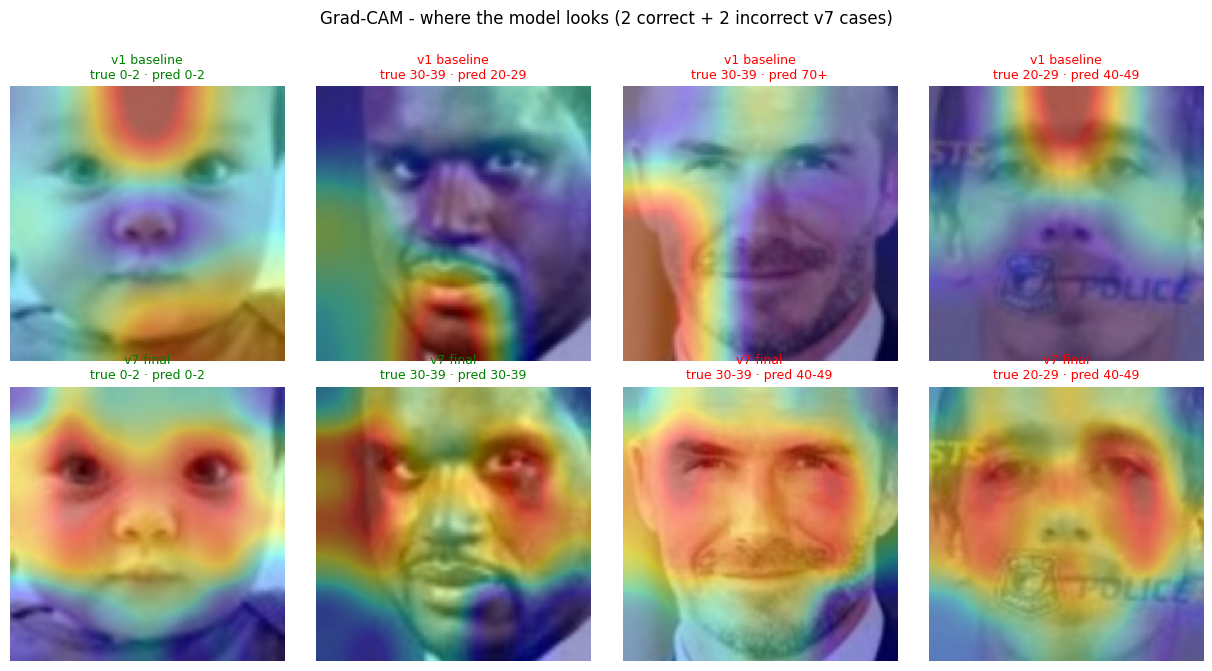

In [73]:
# --- one batched pass to find correct vs incorrect (based on v7, the final model) ---
pred_v7_all = model_v7.predict(X_te224, verbose=0).argmax(1)
correct_idx = np.where(pred_v7_all == y_true_test)[0]
wrong_idx   = np.where(pred_v7_all != y_true_test)[0]

rng   = np.random.default_rng(SEED)
picks = np.concatenate([
    rng.choice(correct_idx, 2, replace=False),   # 2 where v7 is right
    rng.choice(wrong_idx,   2, replace=False),   # 2 where v7 is wrong
])

fig, axes = plt.subplots(2, len(picks), figsize=(3.1*len(picks), 6.6))
for c, idx in enumerate(picks):
    true = AGE_GROUP_LABELS[y_true_test[idx]]
    for r, (tag, gc, X, scale, mdl) in enumerate([
            ("v1 baseline", gc_v1, X_te96,  True,  model_v1),
            ("v7 final",    gc_v7, X_te224, False, model_v7)]):
        x = X[idx:idx+1].astype(np.float32)
        if scale: x = x / 255.0
        hm   = heatmap(gc, x)
        pred = AGE_GROUP_LABELS[int(np.argmax(mdl.predict(x, verbose=0)[0]))]
        big  = np.array(Image.fromarray(np.uint8(255*hm)).resize(
                            (X.shape[1], X.shape[1])))
        axes[r, c].imshow(X[idx]); axes[r, c].imshow(big, cmap="jet", alpha=0.40)
        axes[r, c].axis("off")
        axes[r, c].set_title(f"{tag}\ntrue {true} · pred {pred}", fontsize=9,
                             color="green" if pred == true else "red")

plt.suptitle("Grad-CAM - where the model looks (2 correct + 2 incorrect v7 cases)",
             y=1.01)
plt.tight_layout(); plt.show()

### Attention by Facial Region

Each heat map is resized to a common 24x24 grid and split into vertical thirds, so the two resolutions are directly comparable and each band covers exactly one third of the face.

In [55]:
GRID, N_PER_RACE = 24, 80

def region_profile(gc, X, scale, idxs):
    acc = []
    for i in idxs:
        x = X[i:i+1].astype(np.float32)
        if scale: x = x / 255.0
        hm = heatmap(gc, x)
        hm = tf.image.resize(hm[..., None], [GRID, GRID]).numpy().squeeze()
        s  = hm.sum()
        if s == 0: continue
        hm, t3 = hm/s, GRID//3
        acc.append((hm[:t3].sum()*100, hm[t3:2*t3].sum()*100, hm[2*t3:].sum()*100))
    return np.mean(acc, axis=0)

rows = []
for tag, gc, X, scale in [("v1 baseline", gc_v1, X_te96,  True),
                          ("v7 final",    gc_v7, X_te224, False)]:
    print(f"\n=== {tag} ===")
    print(f"  {'race':<8}{'TOP':>8}{'MID':>8}{'LOW':>8}")
    per = {}
    for race in sorted(test_df["race"].unique()):
        idxs = test_df.index[test_df["race"] == race][:N_PER_RACE]
        per[race] = region_profile(gc, X, scale, idxs)
        print(f"  {race:<8}{per[race][0]:>7.1f}{per[race][1]:>8.1f}{per[race][2]:>8.1f}")
    arr    = np.array(list(per.values()))
    spread = arr.max(axis=0) - arr.min(axis=0)
    rows.append((tag, arr.mean(axis=0), spread))
    print(f"  mean    {arr.mean(axis=0)[0]:>7.1f}{arr.mean(axis=0)[1]:>8.1f}"
          f"{arr.mean(axis=0)[2]:>8.1f}")
    print(f"  spread across races: {spread.sum():.2f}")

print(f"\n{'='*64}")
print("TOP = forehead/hair · MID = eyes/nose · LOW = mouth/chin")
print(f"{'Model':<16}{'TOP':>9}{'MID':>9}{'LOW':>9}{'race spread':>14}")
for tag, mean, spread in rows:
    print(f"{tag:<16}{mean[0]:>8.1f}{mean[1]:>9.1f}{mean[2]:>9.1f}{spread.sum():>13.2f}")
print("\nHigher MID share = more attention on the eye/nose region, where ageing")
print("cues concentrate. Lower race spread = more uniform attention across groups.")



=== v1 baseline ===
  race         TOP     MID     LOW
  Asian      37.6    36.5    25.9
  Black      30.1    37.8    32.1
  Indian     38.5    35.4    26.1
  Other      35.9    34.0    30.1
  White      36.5    38.3    25.1
  mean       35.7    36.4    27.9
  spread across races: 19.76

=== v7 final ===
  race         TOP     MID     LOW
  Asian      35.3    43.5    21.2
  Black      35.3    43.7    21.0
  Indian     35.3    43.7    20.9
  Other      35.9    43.2    20.9
  White      35.0    43.5    21.5
  mean       35.4    43.5    21.1
  spread across races: 2.00

TOP = forehead/hair · MID = eyes/nose · LOW = mouth/chin
Model                 TOP      MID      LOW   race spread
v1 baseline         35.7     36.4     27.9        19.76
v7 final            35.4     43.5     21.1         2.00

Higher MID share = more attention on the eye/nose region, where ageing
cues concentrate. Lower race spread = more uniform attention across groups.


## Confusion Matrix (9 age groups)

Row-normalised, so each row sums to 1 and the diagonal is per-class recall.

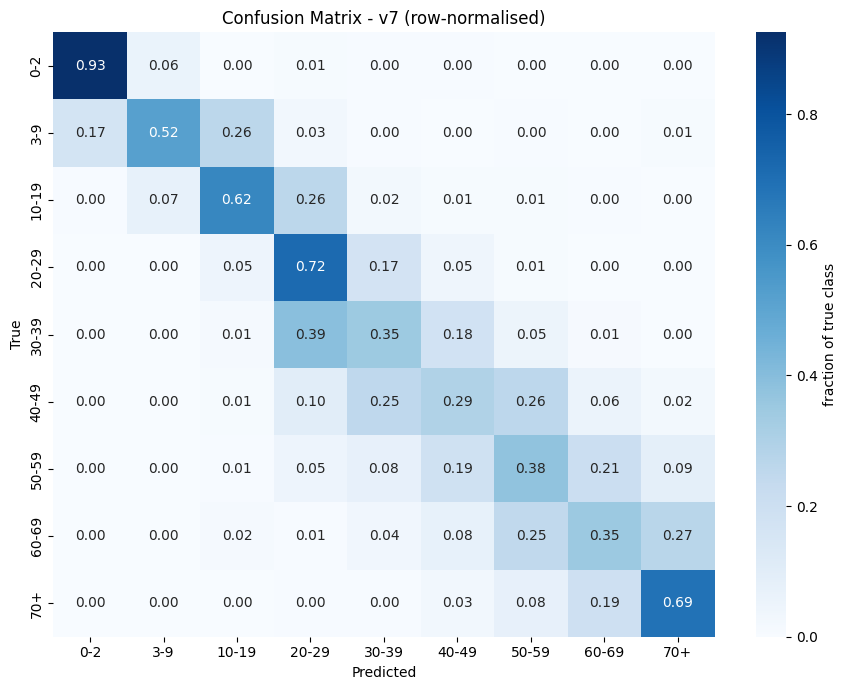

In [56]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true_test, yp_v7, normalize="true")
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=AGE_GROUP_LABELS, yticklabels=AGE_GROUP_LABELS,
            cbar_kws={"label": "fraction of true class"})
plt.title("Confusion Matrix - v7 (row-normalised)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()


In [57]:
exact    = float((y_true_test == yp_v7).mean())
adjacent = float((np.abs(y_true_test - yp_v7) == 1).mean())
far      = float((np.abs(y_true_test - yp_v7) >= 2).mean())

print(f"Exact correct          : {exact:.2%}")
print(f"Off by exactly 1 band  : {adjacent:.2%}")
print(f"Off by 2+ bands        : {far:.2%}")
print(f"\n-> one-off accuracy   : {exact + adjacent:.2%}")
print("\nErrors concentrated next to the diagonal mean the model is rarely")
print("badly wrong - the operationally relevant property for age estimation.")


Exact correct          : 54.69%
Off by exactly 1 band  : 35.60%
Off by 2+ bands        : 9.71%

-> one-off accuracy   : 90.29%

Errors concentrated next to the diagonal mean the model is rarely
badly wrong - the operationally relevant property for age estimation.


## Per-Age x Per-Race Accuracy Grid

An overall average hides intersectional failures. Read the heat map **together with** the count table - a cell backed by fewer than 15 images is noise, not a finding.

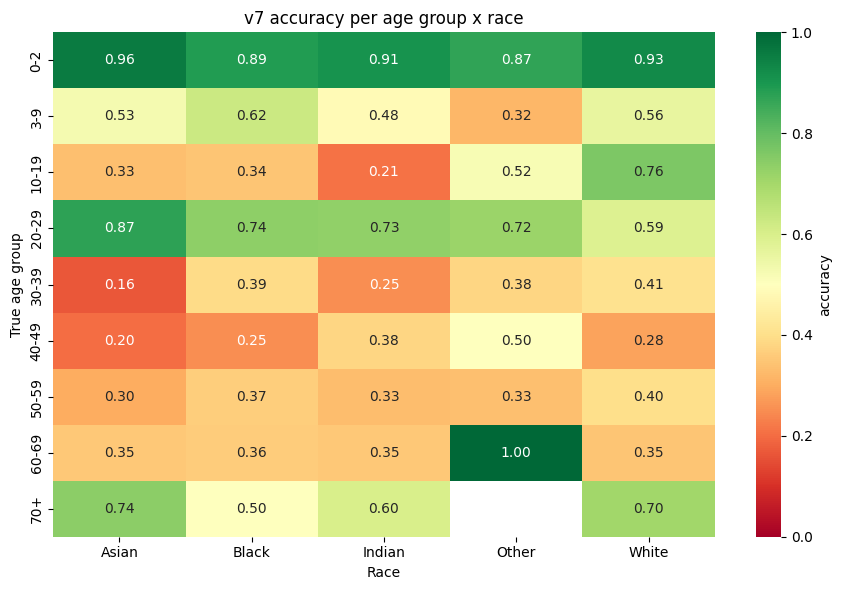

Test-image count per cell (n < 15 is unreliable):

race       Asian  Black  Indian  Other  White
age_group                                    
0-2           95      9      44     38     55
3-9           36      8      31     25    118
10-19          9     32      19     25    144
20-29        197    269     237     92    307
30-39         85    196     103     34    263
40-49         30     64      50     16    177
50-59         10     52      64      9    210
60-69         17     36      17      1    127
70+           27     16      10      0    149

=== WEAKEST RELIABLE CELLS (n >= 15) ===
  Asian    30-39   16.5%  (n=85)
  Asian    40-49   20.0%  (n=30)
  Indian   10-19   21.1%  (n=19)
  Black    40-49   25.0%  (n=64)
  Indian   30-39   25.2%  (n=103)
  White    40-49   28.2%  (n=177)
  Other    3-9     32.0%  (n=25)
  Indian   50-59   32.8%  (n=64)


In [58]:
grid_acc = test_eval.pivot_table(index="age_group", columns="race",
                                 values="correct", aggfunc="mean").reindex(AGE_GROUP_LABELS)
grid_n   = test_eval.pivot_table(index="age_group", columns="race",
                                 values="correct", aggfunc="count").reindex(AGE_GROUP_LABELS)

plt.figure(figsize=(9, 6))
sns.heatmap(grid_acc, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
            cbar_kws={"label": "accuracy"})
plt.title("v7 accuracy per age group x race")
plt.xlabel("Race"); plt.ylabel("True age group")
plt.tight_layout(); plt.show()

print("Test-image count per cell (n < 15 is unreliable):\n")
print(grid_n.fillna(0).astype(int))

flat = [(grid_acc.loc[a, r], grid_n.loc[a, r], a, r)
        for a in grid_acc.index for r in grid_acc.columns
        if pd.notna(grid_n.loc[a, r]) and grid_n.loc[a, r] >= 15]
flat.sort()
print("\n=== WEAKEST RELIABLE CELLS (n >= 15) ===")
for a, n, age, race in flat[:8]:
    print(f"  {race:<8} {age:<7} {a:.1%}  (n={int(n)})")


## Per-Group Recall (equal-opportunity view)

Accuracy can hide poor recall on small classes. Macro recall weights every age band equally instead of letting `20-29` dominate.

In [59]:
print("=== PER-AGE-GROUP RECALL (v7, all races) ===\n")
print(classification_report(y_true_test, yp_v7,
                            target_names=AGE_GROUP_LABELS, zero_division=0))

print("\n=== MACRO-AVERAGED RECALL PER RACE ===\n")
for race in sorted(test_eval["race"].unique()):
    sub = test_eval[test_eval["race"] == race]
    rec = classification_report(sub["y_true"], sub["y_pred"],
                                output_dict=True, zero_division=0)["macro avg"]["recall"]
    print(f"  {race:<8} macro recall {rec:.2%}   (n={len(sub):,})")


=== PER-AGE-GROUP RECALL (v7, all races) ===

              precision    recall  f1-score   support

         0-2       0.85      0.93      0.89       241
         3-9       0.76      0.52      0.62       218
       10-19       0.52      0.62      0.57       229
       20-29       0.67      0.72      0.69      1102
       30-39       0.43      0.35      0.38       681
       40-49       0.27      0.29      0.28       337
       50-59       0.39      0.38      0.38       345
       60-69       0.33      0.35      0.34       198
         70+       0.59      0.69      0.63       202

    accuracy                           0.55      3553
   macro avg       0.54      0.54      0.53      3553
weighted avg       0.54      0.55      0.54      3553


=== MACRO-AVERAGED RECALL PER RACE ===

  Asian    macro recall 49.45%   (n=506)
  Black    macro recall 49.59%   (n=682)
  Indian   macro recall 47.24%   (n=575)
  Other    macro recall 51.57%   (n=240)
  White    macro recall 55.34%   (n=1,550)


## Statistical Confidence: Bootstrap CIs on Per-Race Accuracy

With ~3,500 test images split five ways, some groups have only a few hundred. Resampling 1,000 times shows whether the measured gap is real or an artefact of which images landed in the test set.

In [60]:
rng    = np.random.default_rng(SEED)
N_BOOT = 1000

print("=== 95% BOOTSTRAP CI PER RACE (v7) ===\n")
race_accuracies, ci = {}, {}
for race in sorted(test_eval["race"].unique()):
    sub = test_eval[test_eval["race"] == race]
    idx = sub.index.to_numpy()
    race_accuracies[race] = float(sub["correct"].mean())
    boot = [test_eval.loc[rng.choice(idx, len(idx), replace=True), "correct"].mean()
            for _ in range(N_BOOT)]
    ci[race] = tuple(np.percentile(boot, [2.5, 97.5]))
    print(f"  {race:<8} {race_accuracies[race]:.2%}   "
          f"CI [{ci[race][0]:.2%}, {ci[race][1]:.2%}]   (n={len(sub):,})")

best  = max(race_accuracies, key=race_accuracies.get)
worst = min(race_accuracies, key=race_accuracies.get)
gap   = race_accuracies[best] - race_accuracies[worst]
overlap = ci[best][0] <= ci[worst][1]

print(f"\n  gap {best} - {worst}: {gap*100:.2f}pp")
print(f"  CIs overlap: {overlap}  ->  the gap is",
      "NOT clearly separable from sampling noise" if overlap else
      "statistically credible (not sampling noise)")


=== 95% BOOTSTRAP CI PER RACE (v7) ===

  Asian    66.01%   CI [61.66%, 69.96%]   (n=506)
  Black    52.05%   CI [48.39%, 55.72%]   (n=682)
  Indian   54.09%   CI [50.26%, 58.43%]   (n=575)
  Other    60.42%   CI [54.58%, 66.25%]   (n=240)
  White    51.48%   CI [48.90%, 54.00%]   (n=1,550)

  gap Asian - White: 14.52pp
  CIs overlap: False  ->  the gap is statistically credible (not sampling noise)


## Week 3 Summary

| Analysis | What it answers |
|---|---|
| Grad-CAM, baseline vs final | *Where* each model looks, and how attention shifted |
| Confusion matrix + one-off | *How* the model errs - adjacent bands or far misses |
| Per-age x per-race grid | *Which* intersectional cells fail |
| Per-group recall | Equal-opportunity view beyond raw accuracy |
| Bootstrap CIs | Whether the measured fairness gap survives statistical scrutiny |

Race is never an input to the model, yet a measurable per-race accuracy gap
remains. Removing a protected attribute from the input does not remove bias from
the output - the images themselves carry race-correlated signal, so fairness must
be **measured** rather than assumed from the architecture.


---
# WEEK 4 - Automated Tests & Deployment
---

**Goals:** automated weakness-detection tests with code coverage, a fairness
regression check on the live model, and a deployed web application.


## Automated Tests (pytest with coverage)

Pipeline logic is extracted to a module so it can be imported and tested independently of the notebook.

In [61]:
%%writefile responsible_ai_utils.py
"""Pure pipeline logic extracted from the notebook so pytest can import and test it.
Kept in exact sync with the notebook definitions."""

AGE_GROUP_LABELS = ["0-2", "3-9", "10-19", "20-29", "30-39",
                    "40-49", "50-59", "60-69", "70+"]

RACE_MAP   = {0: "White", 1: "Black", 2: "Asian", 3: "Indian", 4: "Other"}
GENDER_MAP = {0: "Male",  1: "Female"}


def age_to_group(age):
    """Bin a continuous age into one of 9 canonical age groups."""
    if   age <= 2:  return "0-2"
    elif age <= 9:  return "3-9"
    elif age <= 19: return "10-19"
    elif age <= 29: return "20-29"
    elif age <= 39: return "30-39"
    elif age <= 49: return "40-49"
    elif age <= 59: return "50-59"
    elif age <= 69: return "60-69"
    else:           return "70+"


def parse_utk_filename(stem):
    """Parse a UTKFace filename stem 'age_gender_race_timestamp'.
    Returns a dict or None for malformed / non-numeric stems."""
    parts = stem.split("_")
    if len(parts) < 3:
        return None
    try:
        return {
            "age"    : int(parts[0]),
            "gender" : GENDER_MAP.get(int(parts[1]), "Unknown"),
            "race"   : RACE_MAP.get(int(parts[2]),   "Unknown"),
        }
    except ValueError:
        return None


def clean_utk(df):
    """Apply the notebook's cleaning rules: age 1-100, no Unknown labels,
    add the age_group column."""
    out = df.copy()
    out = out[out["age"] >= 1]
    out = out[out["age"] <= 100]
    out = out[out["gender"] != "Unknown"]
    out = out[out["race"]   != "Unknown"]
    out["age_group"] = out["age"].apply(age_to_group)
    return out


def splits_disjoint(*dfs, col="filepath"):
    """True iff no filepath appears in more than one split."""
    seen = set()
    for df in dfs:
        values = set(df[col])
        if seen & values:
            return False
        seen |= values
    return True


def one_off_correct(y_true, y_pred):
    """Fraction of predictions within one age group of the truth."""
    import numpy as np
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float((np.abs(y_true - y_pred) <= 1).mean())


def accuracy_parity_gap(acc_dict):
    """Best-minus-worst group accuracy — our named fairness metric."""
    return max(acc_dict.values()) - min(acc_dict.values())


def fairness_check(acc_dict, max_gap):
    """Weakness detection: True iff the accuracy parity gap is within threshold."""
    return accuracy_parity_gap(acc_dict) <= max_gap


Overwriting responsible_ai_utils.py


In [62]:
%%writefile test_responsible_ai.py
"""Automated test suite — run with:
    pytest test_responsible_ai.py -v --cov=responsible_ai_utils --cov-report=term
"""
import numpy as np
import pandas as pd
import pytest

from responsible_ai_utils import (age_to_group, parse_utk_filename, clean_utk,
                                  splits_disjoint, one_off_correct,
                                  accuracy_parity_gap, fairness_check,
                                  AGE_GROUP_LABELS)


# ---------- age_to_group: every boundary value ----------
@pytest.mark.parametrize("age,expected", [
    (1,  "0-2"),  (2,  "0-2"),
    (3,  "3-9"),  (9,  "3-9"),
    (10, "10-19"), (19, "10-19"),
    (20, "20-29"), (29, "20-29"),
    (30, "30-39"), (39, "30-39"),
    (40, "40-49"), (49, "40-49"),
    (50, "50-59"), (59, "50-59"),
    (60, "60-69"), (69, "60-69"),
    (70, "70+"),   (100, "70+"),
])
def test_age_to_group_boundaries(age, expected):
    assert age_to_group(age) == expected


def test_age_groups_are_canonical():
    # every produced label must be one of the 9 canonical labels
    for age in range(1, 101):
        assert age_to_group(age) in AGE_GROUP_LABELS


# ---------- filename parsing ----------
def test_parse_valid_filename():
    r = parse_utk_filename("25_0_2_20170116174525125")
    assert r == {"age": 25, "gender": "Male", "race": "Asian"}

def test_parse_female_white():
    r = parse_utk_filename("61_1_0_20170109150557335")
    assert r == {"age": 61, "gender": "Female", "race": "White"}

def test_parse_too_few_parts_returns_none():
    assert parse_utk_filename("25_0") is None

def test_parse_non_numeric_returns_none():
    assert parse_utk_filename("abc_0_1_xyz") is None

def test_parse_unknown_codes_mapped():
    r = parse_utk_filename("30_7_9_ts")           # invalid gender/race codes
    assert r["gender"] == "Unknown" and r["race"] == "Unknown"


# ---------- cleaning rules ----------
def _toy_df():
    return pd.DataFrame({
        "filepath": [f"f{i}.jpg" for i in range(6)],
        "age"     : [0, 1, 50, 100, 116, 30],
        "gender"  : ["Male", "Female", "Male", "Female", "Male", "Unknown"],
        "race"    : ["White", "Black", "Unknown", "Asian", "Indian", "Other"],
    })

def test_clean_removes_age_zero_and_over_100():
    out = clean_utk(_toy_df())
    assert out["age"].min() >= 1
    assert out["age"].max() <= 100

def test_clean_removes_unknown_labels():
    out = clean_utk(_toy_df())
    assert "Unknown" not in out["gender"].values
    assert "Unknown" not in out["race"].values

def test_clean_adds_valid_age_group_column():
    out = clean_utk(_toy_df())
    assert "age_group" in out.columns
    assert out["age_group"].isin(AGE_GROUP_LABELS).all()

def test_clean_keeps_expected_rows():
    # rows 1 (age 1) and 3 (age 100) survive; 0, 2, 4, 5 are filtered
    out = clean_utk(_toy_df())
    assert set(out["filepath"]) == {"f1.jpg", "f3.jpg"}


# ---------- split integrity ----------
def test_splits_disjoint_true_for_clean_splits():
    a = pd.DataFrame({"filepath": ["a.jpg", "b.jpg"]})
    b = pd.DataFrame({"filepath": ["c.jpg"]})
    c = pd.DataFrame({"filepath": ["d.jpg", "e.jpg"]})
    assert splits_disjoint(a, b, c)

def test_splits_disjoint_detects_leakage():
    a = pd.DataFrame({"filepath": ["a.jpg", "b.jpg"]})
    b = pd.DataFrame({"filepath": ["b.jpg"]})      # leaked into validation
    assert not splits_disjoint(a, b)


# ---------- metrics ----------
def test_one_off_correct():
    y_true = [3, 3, 3, 3]
    y_pred = [3, 4, 2, 6]        # exact, +1, -1, far
    assert one_off_correct(y_true, y_pred) == pytest.approx(0.75)

def test_accuracy_parity_gap():
    assert accuracy_parity_gap({"A": 0.55, "B": 0.42}) == pytest.approx(0.13)

def test_fairness_check_passes_within_threshold():
    assert fairness_check({"A": 0.50, "B": 0.45}, max_gap=0.10)

def test_fairness_check_fails_beyond_threshold():
    assert not fairness_check({"A": 0.56, "B": 0.42}, max_gap=0.10)


Overwriting test_responsible_ai.py


In [63]:
!pip install pytest pytest-cov -q
# -p no:langsmith_plugin disables an unrelated, broken pytest plugin (langsmith,
# pulled in by other coursework) that would crash pytest at startup. Harmless if
# langsmith isn't installed (e.g. on the cloud JupyterHub).
!pytest test_responsible_ai.py -v -p no:langsmith_plugin --cov=responsible_ai_utils --cov-report=term


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
============================= test session starts ==============================
platform linux -- Python 3.11.0rc1, pytest-9.1.1, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /home/jovyan/vault/face_project/repo/Code
plugins: cov-7.1.0, anyio-4.6.1
collected 34 items                                                             

test_responsible_ai.py::test_age_to_group_boundaries[1-0-2] PASSED       [  2%]
test_responsible_ai.py::test_age_to_group_boundaries[2-0-2] PASSED       [  5%]
test_responsible_ai.py::test_age_to_group_boundaries[3-3-9] PASSED       [  8%]
test_responsible_ai.py::test_age_to_group_boundaries[9-3-9] PASSED       [ 11%]
test_responsible_ai.py::test_age_to_group_boundaries[10-10-19] PASSED    [ 14%]
test_responsible_ai.py::test_age_to_group_boundaries[19-10-19] PASSED    [ 17%]
test_responsible_ai.py::test_age_to_group_boun

## Weakness Detection: Live Fairness Regression Check

A guard that fails if the per-race accuracy gap exceeds an agreed threshold - the kind of check that would gate a deployment.

In [64]:
from responsible_ai_utils import accuracy_parity_gap, fairness_check

MAX_ALLOWED_GAP = 0.20      # 20pp policy ceiling

gap_now = accuracy_parity_gap(race_accuracies)
passed  = fairness_check(race_accuracies, MAX_ALLOWED_GAP)

print("=== LIVE FAIRNESS REGRESSION CHECK (v7) ===\n")
for r, a in sorted(race_accuracies.items(), key=lambda kv: kv[1]):
    print(f"  {r:<8} {a:.2%}")
print(f"\n  measured gap : {gap_now*100:.2f}pp")
print(f"  threshold    : {MAX_ALLOWED_GAP*100:.0f}pp")
print(f"  result       : {'PASS' if passed else 'FAIL'}")
print("\nThe threshold is a policy decision, not a property of the model. It is")
print("recorded explicitly so that any future retraining can be checked against it.")


=== LIVE FAIRNESS REGRESSION CHECK (v7) ===

  White    51.48%
  Black    52.05%
  Indian   54.09%
  Other    60.42%
  Asian    66.01%

  measured gap : 14.52pp
  threshold    : 20pp
  result       : PASS

The threshold is a policy decision, not a property of the model. It is
recorded explicitly so that any future retraining can be checked against it.


## Deployed Application - Alcohol Purchase Age Check

The model is deployed as a Streamlit web application for a concrete use case:
**checking whether a customer appears old enough to purchase alcohol.**

The design point is what the app does when it *cannot* be sure. The model
predicts age **bands**, and the `10-19` band straddles the legal threshold of 18 -
it cannot separate a 17-year-old from a 19-year-old. Rather than guessing, the app
computes **P(age >= threshold)** from the full probability distribution and routes
uncertain cases to human ID verification (EU AI Act Article 14, human oversight).

| P(age >= threshold) | Outcome |
|---|---|
| >= 0.95 | auto-clear |
| <= 0.05 | auto-reject |
| otherwise | **human ID verification required** |

Under the German Jugendschutzgesetz there are **two** thresholds: **16+** for beer,
wine and sparkling wine, and **18+** for spirits. The app exposes this as a product
selector, making the point explicit: the thresholds are **policy settings, not
technical constants.**

The system never refuses a sale on its own - staff make the final decision and may
request physical ID at any time.

In [65]:
# derive P(age>=18 | band 10-19) from the data rather than assuming uniform
sub  = df_utk_clean[(df_utk_clean.age >= 10) & (df_utk_clean.age <= 19)]
FRAC = float((sub.age >= 18).mean())
print(f"FRAC_18_19 = {FRAC:.4f}   (share of the 10-19 band aged 18+, n={len(sub):,})")

review = float((yp_v7 == 2).mean())
u18    = test_eval[test_eval["y_true"].isin([0, 1, 2])]
leak   = float((u18["y_pred"] >= 3).mean())
print(f"manual review rate (predicted 10-19)   : {review:.1%}")
print(f"under-18 faces auto-approved as 20-29+ : {leak:.1%}")
print("\n^ the second figure is the residual risk that abstention does NOT catch")


FRAC_18_19 = 0.2351   (share of the 10-19 band aged 18+, n=1,531)
manual review rate (predicted 10-19)   : 7.6%
under-18 faces auto-approved as 20-29+ : 12.4%

^ the second figure is the residual risk that abstention does NOT catch


In [75]:
# --- Fairness audit of the DEPLOYED decision policy (same rule as the app) ---
FRAC18 = float((df_utk_clean[df_utk_clean.age.between(10, 19)].age >= 18).mean())
P_APPROVE, P_REJECT = 0.95, 0.05

probs = model_v7.predict(X_te224, verbose=0)
p18   = probs[:, 3:].sum(1) + probs[:, 2] * FRAC18

aud = test_eval.copy()
aud["p18"]      = p18
aud["decision"] = np.where(p18 >= P_APPROVE, "auto-clear",
                  np.where(p18 <= P_REJECT,  "auto-reject", "human review"))

if "age" in aud.columns:
    minors, note = aud["age"] < 18, "(true continuous age)"
else:
    minors, note = aud["y_true"].isin([0, 1]), \
                   "(band proxy: 0-2 and 3-9 only, since 10-19 straddles 18)"

print(f"=== SAFETY: under-18 wrongly auto-cleared {note} ===")
print(f"overall: {(aud.loc[minors, 'decision'] == 'auto-clear').mean():.2%}\n")
print(aud[minors].assign(leaked=lambda d: d.decision == "auto-clear")
        .groupby("race")["leaked"].agg(["mean", "sum", "count"]))

print("\n=== FAIRNESS: how often each group is sent to human ID check ===")
print(aud.assign(review=lambda d: d.decision == "human review")
        .groupby("race")["review"].agg(["mean", "count"]))

print("\n=== Decision mix by race ===")
print(pd.crosstab(aud["race"], aud["decision"], normalize="index").round(3))

=== SAFETY: under-18 wrongly auto-cleared (true continuous age) ===
overall: 2.53%

            mean  sum  count
race                        
Asian   0.007194    1    139
Black   0.076923    3     39
Indian  0.035714    3     84
Other   0.025316    2     79
White   0.023973    7    292

=== FAIRNESS: how often each group is sent to human ID check ===
            mean  count
race                   
Asian   0.205534    506
Black   0.177419    682
Indian  0.186087    575
Other   0.262500    240
White   0.218065   1550

=== Decision mix by race ===
decision  auto-clear  auto-reject  human review
race                                           
Asian          0.549        0.245         0.206
Black          0.804        0.019         0.177
Indian         0.717        0.097         0.186
Other          0.554        0.183         0.262
White          0.710        0.072         0.218


In [78]:
# --- Age-controlled bias check + confidence intervals ---

# 1. Adults 25+ should ALL be auto-cleared, so any other outcome is model error,
#    not a real age difference. This isolates bias from the age distribution.
adults = aud[aud["age"] >= 25]
print("=== Adults (25+): wrongly NOT auto-cleared, by race (age-controlled) ===")
print(adults.assign(err=lambda d: d.decision != "auto-clear")
        .groupby("race")["err"].agg(["mean", "sum", "count"]).round(3))

# 2. Bootstrap CIs — subgroup counts are small, so point estimates need error bars.
rng = np.random.default_rng(SEED)
def boot_ci(v, n=2000):
    v = np.asarray(v, float)
    if len(v) == 0:
        return (np.nan, np.nan)
    return np.percentile(rng.choice(v, (n, len(v)), replace=True).mean(1), [2.5, 97.5])

print("\n=== Under-18 auto-clear rate, 95% CI by race ===")
for r, g in aud[minors].groupby("race"):
    rate   = (g.decision == "auto-clear").mean()
    lo, hi = boot_ci(g.decision == "auto-clear")
    print(f"  {r:7s} {rate:6.1%}   CI [{lo:5.1%}, {hi:5.1%}]   n={len(g)}")

print("\n=== Adult (25+) wrongful non-clear rate, 95% CI by race ===")
for r, g in adults.groupby("race"):
    rate   = (g.decision != "auto-clear").mean()
    lo, hi = boot_ci(g.decision != "auto-clear")
    print(f"  {r:7s} {rate:6.1%}   CI [{lo:5.1%}, {hi:5.1%}]   n={len(g)}")

=== Adults (25+): wrongly NOT auto-cleared, by race (age-controlled) ===
         mean  sum  count
race                     
Asian   0.199   58    291
Black   0.112   63    562
Indian  0.121   50    414
Other   0.102   12    118
White   0.094  108   1146

=== Under-18 auto-clear rate, 95% CI by race ===
  Asian     0.7%   CI [ 0.0%,  2.2%]   n=139
  Black     7.7%   CI [ 0.0%, 17.9%]   n=39
  Indian    3.6%   CI [ 0.0%,  8.3%]   n=84
  Other     2.5%   CI [ 0.0%,  6.3%]   n=79
  White     2.4%   CI [ 0.7%,  4.1%]   n=292

=== Adult (25+) wrongful non-clear rate, 95% CI by race ===
  Asian    19.9%   CI [15.5%, 24.7%]   n=291
  Black    11.2%   CI [ 8.5%, 13.9%]   n=562
  Indian   12.1%   CI [ 8.9%, 15.2%]   n=414
  Other    10.2%   CI [ 5.1%, 16.1%]   n=118
  White     9.4%   CI [ 7.8%, 11.2%]   n=1146


### Application Source

In [93]:
%%writefile /home/jovyan/age_app.py
"""Alcohol Purchase Age Check — decision support with human oversight."""
from pathlib import Path
import numpy as np, pandas as pd
from PIL import Image
import streamlit as st
import tensorflow as tf
from responsible_ai_utils import p_at_least, decide

DATA       = Path("/home/jovyan/vault/face_project/data")
MODEL_PATH = DATA / "v7_final_224.keras"
BANDS = ["0-2","3-9","10-19","20-29","30-39","40-49","50-59","60-69","70+"]
LOW   = {"30-39","40-49","50-59"}

P_APPROVE, P_REJECT = 0.95, 0.05
PRODUCTS = {"Beer / Wine / Sparkling (16+)": 16, "Spirits / Liquor (18+)": 18}

st.set_page_config(page_title="Alcohol Age Check", page_icon="🪪", layout="centered")

st.markdown("""
<style>

/* Remove Streamlit top padding */
.block-container{
    padding-top:0rem !important;
    padding-bottom:2rem;
}

/* Remove the empty header space */
header[data-testid="stHeader"]{
    height:0;
    background:transparent;
}

/* Hide the toolbar spacing */
[data-testid="stToolbar"]{
    display:none;
}

/* Remove extra top margin */
.main .block-container{
    margin-top:-55px;
}
/* ---------- Background ---------- */

.stApp{
    background:
        linear-gradient(rgba(5,8,15,.75), rgba(5,8,15,.78)),
        url("https://magazine.medlineplus.gov/images/uploads/main_images/Alcohol_use-main.jpg");
    background-size:cover;
    background-position:center;
    background-attachment:fixed;
}


/* Remove default white container */
.main .block-container{
    padding-top:2rem;
    padding-bottom:3rem;
}


/* ---------- Main Title ---------- */

h1{
    color:white !important;
    text-align:center;
    font-size:3rem !important;
    font-weight:800 !important;
    letter-spacing:-1px;
    margin-bottom:10px;

    text-shadow:
        0px 0px 10px rgba(255,255,255,.2),
        0px 0px 20px rgba(0,0,0,.5);
}

h2,h3,h4{
    color:white !important;
}

p,label,span{
    color:#ECECEC !important;
}


/* ---------- Glass Cards ---------- */

[data-testid="stVerticalBlock"] > div{
    background:rgba(18,20,28,.55);
    border:1px solid rgba(255,255,255,.08);
    border-radius:20px;
    backdrop-filter:blur(15px);
    padding:18px;
}


/* ---------- Radio ---------- */

.stRadio > div{
    background:rgba(255,255,255,.04);
    border-radius:15px;
    padding:10px;
}


/* ---------- Upload ---------- */

[data-testid="stFileUploader"]{
    border-radius:18px;
    border:2px dashed rgba(255,255,255,.25);
    background:rgba(255,255,255,.03);
}


/* ---------- Camera ---------- */

[data-testid="stCameraInput"]{
    border-radius:18px;
}


/* ---------- Buttons ---------- */

.stButton>button{
    width:100%;
    border:none;
    border-radius:15px;
    background:linear-gradient(135deg,#0EA5E9,#2563EB);
    color:white;
    font-weight:bold;
    transition:.3s;
}

.stButton>button:hover{

    transform:translateY(-2px);

    box-shadow:0px 8px 30px rgba(59,130,246,.45);

}


/* ---------- Metric ---------- */

[data-testid="stMetric"]{

    background:rgba(255,255,255,.05);

    padding:20px;

    border-radius:18px;

    border:1px solid rgba(255,255,255,.08);

}

[data-testid="stMetricValue"]{

    color:#4ADE80 !important;

    font-size:40px !important;

}

[data-testid="stMetricLabel"]{

    color:white !important;

}


/* ---------- Image ---------- */

img{

    border-radius:20px;

}


/* ---------- Verdict Cards ---------- */

.verdict{

    border-radius:22px;

    padding:25px;

    text-align:center;

    font-size:24px;

    font-weight:700;

    margin-top:15px;

    margin-bottom:20px;

    backdrop-filter:blur(18px);

    box-shadow:0px 10px 35px rgba(0,0,0,.35);

}

.ok{

    background:rgba(34,197,94,.22);

    color:#BBF7D0;

    border:2px solid rgba(34,197,94,.5);

}

.no{

    background:rgba(239,68,68,.22);

    color:#FECACA;

    border:2px solid rgba(239,68,68,.5);

}

.maybe{

    background:rgba(251,191,36,.22);

    color:#FDE68A;

    border:2px solid rgba(251,191,36,.5);

}


/* ---------- Progress Bar ---------- */

[data-testid="stProgressBar"]{

    border-radius:12px;

}


/* ---------- Caption ---------- */

caption{

    color:#ddd;

}


/* ---------- Footer ---------- */

footer{

    visibility:hidden;

}


/* ---------- Scrollbar ---------- */

::-webkit-scrollbar{

    width:8px;

}

::-webkit-scrollbar-thumb{

    background:#444;

    border-radius:10px;

}

</style>
""", unsafe_allow_html=True)

try:
    import cv2
    _C = cv2.CascadeClassifier(cv2.data.haarcascades +
                               "haarcascade_frontalface_default.xml")
    HAVE_CV2 = True
except Exception:
    HAVE_CV2 = False

def crop_face(pil):
    arr = np.array(pil.convert("RGB"))
    if HAVE_CV2:
        g = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
        f = _C.detectMultiScale(g, 1.05, 3, minSize=(40,40))
        if len(f):
            x,y,w,h = max(f, key=lambda b: b[2]*b[3]); m = int(.25*w)
            return Image.fromarray(arr[max(0,y-m):y+h+m, max(0,x-m):x+w+m]), True
    h,w = arr.shape[:2]; s = min(h,w)
    return Image.fromarray(arr[(h-s)//2:(h-s)//2+s, (w-s)//2:(w-s)//2+s]), False

@st.cache_resource
def load():
    m = tf.keras.models.load_model(MODEL_PATH, compile=False)
    def raw(mm):
        for l in mm.layers:
            if isinstance(l, tf.keras.layers.Rescaling): return True
            if isinstance(l, tf.keras.Model) and raw(l): return True
        return False
    return m, raw(m)
model, RAW = load()

@st.cache_data
def band_frac(threshold):
    """Share of the 10-19 band aged >= threshold, derived from data."""
    try:
        df = pd.concat([pd.read_csv(DATA/f) for f in
                        ["train_df.csv","val_df.csv","test_df.csv"]], ignore_index=True)
        s = df[(df.age >= 10) & (df.age <= 19)]
        return float((s.age >= threshold).mean())
    except Exception:
        return {16: 0.40, 18: 0.20}.get(threshold, 0.20)

st.title("Age-Restricted Sales — Alcohol Purchase Check")



product = st.radio("Product category", list(PRODUCTS), horizontal=True)
PURCHASE_AGE = PRODUCTS[product]

st.caption(f"Estimates P(age >= {PURCHASE_AGE}) from a face photo. The German "
           f"Jugendschutzgesetz sets 16+ for beer/wine and 18+ for spirits. "
           f"Decision support with human oversight - not an official ID check.")

mode = st.radio("Input", ["Upload", "Camera"], horizontal=True)
img = None
if mode == "Upload":
    up = st.file_uploader("Upload a face photo", type=["jpg","jpeg","png"])
    if up: img = Image.open(up)
else:
    shot = st.camera_input("Take a photo")
    if shot: img = Image.open(shot)

if img is not None:
    face, found = crop_face(img)
    x = np.asarray(face.convert("RGB").resize((224,224)), np.float32)[None]
    if not RAW: x /= 255.0
    p = model.predict(x, verbose=0)[0]
    i = int(np.argmax(p)); band, conf = BANDS[i], float(p[i])

    P = p_at_least(p, band_frac(PURCHASE_AGE))
    verdict = decide(P, P_APPROVE, P_REJECT)

    if verdict == "auto-clear":
        cls, txt = "ok", f"MAY PROCEED — {P:.0%} likely aged {PURCHASE_AGE}+"
    elif verdict == "auto-reject":
        cls, txt = "no", (f"SALE NOT PERMITTED WITHOUT ID — only {P:.0%} likely "
                          f"aged {PURCHASE_AGE}+")
    else:
        cls, txt = "maybe", (f"HUMAN ID VERIFICATION REQUIRED — {P:.0%} likely aged "
                             f"{PURCHASE_AGE}+, below the {P_APPROVE:.0%} auto-clear "
                             f"threshold. Check official ID.")
    st.markdown(f'<div class="verdict {cls}">{txt}</div>', unsafe_allow_html=True)

    c1, c2 = st.columns(2)
    with c1:
        st.image(face, caption="face analysed" + ("" if found else " (centre crop)"),
                 use_container_width=True)
    with c2:
        st.metric(f"P(age >= {PURCHASE_AGE})", f"{P:.1%}")
        st.write(f"**Predicted band:** {band}  ({conf:.0%} confidence)")
        if not found: st.warning("No face detected - use a clear frontal photo.")
        if band in LOW: st.warning(f"'{band}' is a low-reliability band.")

    st.subheader("Confidence across all age bands")
    st.bar_chart(pd.DataFrame({"band":BANDS,"confidence":p}).set_index("band"))

st.divider()
st.caption(f"Policy: auto-clear >= {P_APPROVE:.0%}, auto-reject <= {P_REJECT:.0%}, "
           f"otherwise human ID verification (EU AI Act Art. 14). Staff may request "
           f"ID at any time; age estimation must never be the sole basis for refusing "
           f"a sale. Thresholds are policy settings under the German "
           f"Jugendschutzgesetz, not technical constants. Model: v7.")

Overwriting /home/jovyan/age_app.py


### Launch

Streamlit serves on a local port, which JupyterHub does not expose. `cloudflared` opens a public tunnel to it - a standalone binary, so it changes no Python packages. The cell is self-healing: it reinstalls anything a VM restart wiped, and launches Streamlit through `python -m` so it does not depend on `PATH`.

In [90]:
import sys, os, subprocess, time, re, pathlib

try:
    import streamlit  # noqa
    print("streamlit: ok")
except ImportError:
    print("installing streamlit ...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "streamlit", "opencv-python-headless", "numpy<2"])

if not os.path.exists("cloudflared"):
    print("downloading cloudflared ...")
    subprocess.run(["wget", "-q",
        "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64",
        "-O", "cloudflared"])
    os.chmod("cloudflared", 0o755)
print("cloudflared:", "ok" if os.path.exists("cloudflared") else "MISSING")

subprocess.run("pkill -f streamlit; pkill -f 'cloudflared tunnel'",
               shell=True, stderr=subprocess.DEVNULL)
time.sleep(2)

subprocess.Popen([sys.executable, "-m", "streamlit", "run", "/home/jovyan/age_app.py",
                  "--server.port", "8501", "--server.address", "127.0.0.1",
                  "--server.headless", "true"],
                 stdout=open("st.log", "w"), stderr=subprocess.STDOUT)
time.sleep(14)

subprocess.Popen(["./cloudflared", "tunnel", "--url", "http://127.0.0.1:8501",
                  "--no-autoupdate"],
                 stdout=open("cf.log", "w"), stderr=subprocess.STDOUT)

url = None
for _ in range(25):
    time.sleep(2)
    m = re.search(r"https://[a-z0-9-]+\.trycloudflare\.com",
                  pathlib.Path("cf.log").read_text())
    if m:
        url = m.group(0); break

print("\nPUBLIC URL:", url or "NOT FOUND - run:  !cat cf.log   and   !cat st.log")



installing streamlit ...



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


cloudflared: ok

PUBLIC URL: https://edges-guards-teaching-deborah.trycloudflare.com


In [91]:
p = "/home/jovyan/vault/face_project/repo/Code/responsible_ai_utils.py"
lines = open(p).read().splitlines(True)
lines = [l for l in lines if not l.lstrip().startswith("%%writefile")]
open(p, "w").write("".join(lines))
print("cleaned. first line is now:")
print(open(p).readline())

cleaned. first line is now:
"""Pure pipeline logic extracted from the notebook so pytest can import and test it.

